# S-JEPA Pretraining with Braindecode Backbone

Custom self-supervised pretraining notebook for S-JEPA-style masked latent prediction.

This notebook intentionally reuses the **engineering style** of
`lee2019_ssvep_finetune_sjepa_prelocal.ipynb` for:

- setup
- configuration
- artifact logging
- reproducibility
- validation

But this notebook is **not** a downstream classifier notebook.

It is the starter notebook for building a custom pretraining pipeline around:

- Braindecode `SignalJEPA` backbone components
- random spatial block masking
- teacher / student routing
- masked-token prediction
- EMA teacher updates

Sections 1 and 2 are scaffolded here. Continue implementation from Section 3 onward
by following the Copilot instructions and stories files.

# 1. Setup

## 1.1. Import Libraries

In [1]:
import sys
from pathlib import Path
import platform
import json
import hashlib
from datetime import datetime
import builtins
import random
from copy import deepcopy

import mne
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from braindecode.models import SignalJEPA
from braindecode.datasets import MOABBDataset
from braindecode.datasets.base import BaseConcatDataset
from braindecode.preprocessing import Preprocessor, preprocess
from braindecode.preprocessing.windowers import create_fixed_length_windows

from moabb.datasets import Lee2019_MI, Lee2019_ERP, Lee2019_SSVEP

import matplotlib.pyplot as plt
from matplotlib.patches import Circle

print("Imports loaded successfully.")

Imports loaded successfully.


## 1.2. Runtime & Path Validation

In [2]:
print("Runtime Environment:")
print(f"  - Python:   {sys.version}")
print(f"  - Platform: {platform.platform()}")

NOTEBOOK_DIR = Path.cwd()
print(f"\nWorking directory: {NOTEBOOK_DIR}")

Runtime Environment:
  - Python:   3.11.14 | packaged by conda-forge | (main, Jan 27 2026, 00:01:01) [Clang 19.1.7 ]
  - Platform: macOS-26.2-arm64-arm-64bit

Working directory: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA


# 2. Configuration

## 2.1. Config

In [ ]:
CONFIG = {
    # Paths
    "artifact_dir": str(NOTEBOOK_DIR / "artifacts" / "lee-2019-s-jepa-pretraining"),

    # Reproducibility
    "seed": 42,

    # Lee2019 pooled pretraining data (paper-aligned split)
    "paradigm_names": ["SSVEP"], # ["MI", "ERP", "SSVEP"]
    "train_subject_ids": list(range(49, 53)),
    "val_subject_ids": list(range(53, 55)),
    "excluded_subject_ids": list(range(1, 49)),

    # Preprocessing
    "sfreq": 128,
    "bandpass_low": 0.5,
    "bandpass_high": 40.0,
    "pretrain_duration_s": 16.0, # [1, 4, 16]
    "sampling_interval_s": 16,

    # Masking (paper-style spatial diameter settings)
    "masking_strategy": "random_spatial_block_radius",
    "mask_diameter_percent": 60, # [40, 60, 80]

    # Predictor architecture
    "predictor_n_layers": 4,
    "predictor_nhead": 8,
    "predictor_dim_feedforward": 256,

    # Training
    "batch_size": 32,
    "n_epochs": 300,
    "ema_decay": 0.996,
    "early_stopping_patience": 50,

    # Device: "auto" | "cpu" | "cuda" | "mps"
    "device": "auto",
}

## 2.2. Create Artifact Directory

In [4]:
def create_run_id():
    """Generate a run ID from timestamp plus config hash."""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")
    config_str = json.dumps(CONFIG, sort_keys=True, default=str)
    config_hash = hashlib.md5(config_str.encode()).hexdigest()[:8]
    return f"{timestamp}_{config_hash}"

RUN_ID = create_run_id()
ARTIFACT_DIR = Path(CONFIG["artifact_dir"]) / RUN_ID
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Run ID:        {RUN_ID}")
print(f"Artifact dir:  {ARTIFACT_DIR}")

Run ID:        20260326_1351_86b6b8c6
Artifact dir:  /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/lee-2019-s-jepa-pretraining/20260326_1351_86b6b8c6


## 2.3. Initialize Logger

In [5]:
LOG_PATH = ARTIFACT_DIR / "run.log"
_LOG_FILE_HANDLE = open(LOG_PATH, "a", buffering=1)

def _timestamped_print(*args, **kwargs):
    """Print to notebook output and append the same message to run.log."""
    sep = kwargs.pop("sep", " ")
    end = kwargs.pop("end", "\n")
    flush = kwargs.pop("flush", False)
    file = kwargs.pop("file", None)

    message = sep.join(str(arg) for arg in args)

    leading_newlines = len(message) - len(message.lstrip("\n"))
    message_body = message[leading_newlines:]

    def _write_target(text):
        if file is None:
            sys.__stdout__.write(text) # type: ignore
            if flush:
                sys.__stdout__.flush() # type: ignore
        else:
            file.write(text)
            if flush and hasattr(file, "flush"):
                file.flush()

    if leading_newlines > 0:
        blanks = "\n" * leading_newlines
        _write_target(blanks)
        _LOG_FILE_HANDLE.write(blanks)

    if message_body:
        ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        stamped = f"[{ts}] {message_body}"
        _write_target(stamped + end)
        _LOG_FILE_HANDLE.write(stamped + end)
    else:
        _write_target(end)
        _LOG_FILE_HANDLE.write(end)

    if flush:
        _LOG_FILE_HANDLE.flush()

builtins.print = _timestamped_print

print("Timestamped logger initialized.")
print(f"Log path: {LOG_PATH}")

[2026-03-26 13:51:02] Timestamped logger initialized.
[2026-03-26 13:51:02] Log path: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/lee-2019-s-jepa-pretraining/20260326_1351_86b6b8c6/run.log


## 2.4. Device Configuration

In [6]:
def resolve_device(device):
    """Resolve the compute device from config."""
    if device == "cpu":
        return torch.device("cpu")
    if device == "cuda":
        return torch.device("cuda")
    if device == "mps":
        return torch.device("mps")

    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = resolve_device(CONFIG["device"])
print(f"Using device: {DEVICE}")

[2026-03-26 13:51:02] Using device: mps


## 2.5. Deterministic Seeding

In [7]:
def set_seed(seed):
    """Set all major random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(CONFIG["seed"])
print(f"Seed set to: {CONFIG['seed']}")

[2026-03-26 13:51:02] Seed set to: 42


## 2.6. Save Configuration

In [8]:
print("=" * 70)
print("CONFIGURATION")
print("=" * 70)
for key in sorted(CONFIG.keys()):
    print(f"  {key}: {CONFIG[key]}")
print("=" * 70)

config_path = ARTIFACT_DIR / "config.json"
with open(config_path, "w") as f:
    json.dump(CONFIG, f, indent=2)

print(f"Configuration saved to: {config_path}")

[2026-03-26 13:51:02] ======================================================================
[2026-03-26 13:51:02] CONFIGURATION
[2026-03-26 13:51:02] ======================================================================
[2026-03-26 13:51:02]   artifact_dir: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/lee-2019-s-jepa-pretraining
[2026-03-26 13:51:02]   bandpass_high: 40.0
[2026-03-26 13:51:02]   bandpass_low: 0.5
[2026-03-26 13:51:02]   batch_size: 30
[2026-03-26 13:51:02]   device: auto
[2026-03-26 13:51:02]   early_stopping_patience: 50
[2026-03-26 13:51:02]   ema_decay: 0.996
[2026-03-26 13:51:02]   excluded_subject_ids: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48]
[2026-03-26 13:51:02]   mask_diameter_percent: 60
[2026-03-26 13:51:02]   masking_strategy: random_spatial_block_radius
[2026-03-26 13:5

# 3. Data

## 3.1. Lee2019 Pretraining Pool

Load the three Lee2019 paradigms separately and pool them only after consistent preprocessing.

Paradigms included for pretraining:
- Lee2019 MI
- Lee2019 ERP
- Lee2019 SSVEP

In [9]:
LEE2019_DATASET_BUILDERS = {
    "MI": Lee2019_MI,
    "ERP": Lee2019_ERP,
    "SSVEP": Lee2019_SSVEP,
}


def make_lee2019_dataset(paradigm_name, sessions=(1, 2)):
    """Instantiate one Lee2019 paradigm dataset.

    Parameters
    ----------
    paradigm_name : str
        One of "MI", "ERP", or "SSVEP".
    sessions : tuple[int, ...]
        Lee2019 sessions to include.

    Returns
    -------
    moabb.datasets.base.BaseDataset
    """
    dataset_cls = LEE2019_DATASET_BUILDERS[paradigm_name]
    return dataset_cls(sessions=sessions)


def load_lee2019_paradigm_pool(paradigm_name, subject_ids, split_name):
    """Load one Lee2019 paradigm pool for a given subject split."""
    dataset_obj = make_lee2019_dataset(
        paradigm_name,
    )
    concat_ds = MOABBDataset(dataset_obj, subject_ids=subject_ids)

    run_ids = sorted(set(str(ds.description["run"]) for ds in concat_ds.datasets))
    print(f"Loaded Lee2019 {paradigm_name} for {split_name}:")
    print(f"  Subjects:   {subject_ids}")
    print(f"  Runs:       {run_ids}")
    print(f"  Recordings: {len(concat_ds.datasets)}")
    return concat_ds


def combine_concat_datasets(concat_datasets):
    """Combine multiple BaseConcatDataset objects into one pooled dataset."""
    combined_datasets = []
    for concat_ds in concat_datasets:
        combined_datasets.extend(concat_ds.datasets)
    return BaseConcatDataset(combined_datasets)

In [10]:
TRAIN_SUBJECTS = CONFIG["train_subject_ids"]
VAL_SUBJECTS = CONFIG["val_subject_ids"]
DOWNSTREAM_ONLY_SUBJECTS = CONFIG["excluded_subject_ids"]

print("Lee2019 paper-aligned subject split:")
print(f"  Train subjects:                {TRAIN_SUBJECTS}")
print(f"  Validation subjects:           {VAL_SUBJECTS}")
print(f"  Excluded downstream subjects:  {DOWNSTREAM_ONLY_SUBJECTS}")

TRAIN_PARADIGM_DATASETS = {}
VAL_PARADIGM_DATASETS = {}

for paradigm_name in CONFIG["paradigm_names"]:
    TRAIN_PARADIGM_DATASETS[paradigm_name] = load_lee2019_paradigm_pool(
        paradigm_name=paradigm_name,
        subject_ids=TRAIN_SUBJECTS,
        split_name="train",
    )
    VAL_PARADIGM_DATASETS[paradigm_name] = load_lee2019_paradigm_pool(
        paradigm_name=paradigm_name,
        subject_ids=VAL_SUBJECTS,
        split_name="validation",
    )

TRAIN_RAW_DATASET = combine_concat_datasets(list(TRAIN_PARADIGM_DATASETS.values()))
VAL_RAW_DATASET = combine_concat_datasets(list(VAL_PARADIGM_DATASETS.values()))

print("\nCombined Lee2019 pretraining pools:")
print(f"  Train recordings:      {len(TRAIN_RAW_DATASET.datasets)}")
print(f"  Validation recordings: {len(VAL_RAW_DATASET.datasets)}")
print(f"  Total pooled recordings: {len(TRAIN_RAW_DATASET.datasets) + len(VAL_RAW_DATASET.datasets)}")

[2026-03-26 13:51:02] Lee2019 paper-aligned subject split:
[2026-03-26 13:51:02]   Train subjects:                [49, 50, 51, 52]
[2026-03-26 13:51:02]   Validation subjects:           [53, 54]
[2026-03-26 13:51:02]   Excluded downstream subjects:  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48]
[2026-03-26 13:51:55] Loaded Lee2019 SSVEP for train:
[2026-03-26 13:51:55]   Subjects:   [49, 50, 51, 52]
[2026-03-26 13:51:55]   Runs:       ['1train']
[2026-03-26 13:51:55]   Recordings: 8
[2026-03-26 13:52:23] Loaded Lee2019 SSVEP for validation:
[2026-03-26 13:52:23]   Subjects:   [53, 54]
[2026-03-26 13:52:23]   Runs:       ['1train']
[2026-03-26 13:52:23]   Recordings: 4

[2026-03-26 13:52:23] Combined Lee2019 pretraining pools:
[2026-03-26 13:52:23]   Train recordings:      8
[2026-03-26 13:52:23]   Validation recordings: 4
[2026-03-26 13:52:23]   Tota

## 3.2. Pretraining Window Parameters

In [11]:
def compute_pretraining_window_params(sfreq, pretrain_duration_s, sampling_interval_s):
    """Compute paper-aligned pretraining window parameters.

    Parameters
    ----------
    sfreq : float
    pretrain_duration_s : float
        Supported durations: 1.0, 4.0, 16.0 seconds.
    sampling_interval_s : float
        Fixed interval between extracted windows.

    Returns
    -------
    window_size_samples : int
    sampling_interval_samples : int
    """
    if pretrain_duration_s not in {1.0, 4.0, 16.0}:
        raise ValueError(
            f"pretrain_duration_s must be one of {{1.0, 4.0, 16.0}}, got {pretrain_duration_s}"
        )

    window_size_samples = round(pretrain_duration_s * sfreq)
    sampling_interval_samples = round(sampling_interval_s * sfreq)

    if window_size_samples <= 0:
        raise ValueError(f"window_size_samples must be > 0, got {window_size_samples}")
    if sampling_interval_samples <= 0:
        raise ValueError(
            f"sampling_interval_samples must be > 0, got {sampling_interval_samples}"
        )

    print("Pretraining window parameters:")
    print(f"  sfreq:                      {sfreq} Hz")
    print(f"  pretrain_duration_s:        {pretrain_duration_s} s")
    print(f"  sampling_interval_s:        {sampling_interval_s} s")
    print(f"  window_size_samples:        {window_size_samples}")
    print(f"  sampling_interval_samples:  {sampling_interval_samples}")

    return window_size_samples, sampling_interval_samples


WINDOW_SIZE_SAMPLES, SAMPLING_INTERVAL_SAMPLES = compute_pretraining_window_params(
    sfreq=CONFIG["sfreq"],
    pretrain_duration_s=CONFIG["pretrain_duration_s"],
    sampling_interval_s=CONFIG["sampling_interval_s"],
)

[2026-03-26 13:52:24] Pretraining window parameters:
[2026-03-26 13:52:24]   sfreq:                      128 Hz
[2026-03-26 13:52:24]   pretrain_duration_s:        16.0 s
[2026-03-26 13:52:24]   sampling_interval_s:        16 s
[2026-03-26 13:52:24]   window_size_samples:        2048
[2026-03-26 13:52:24]   sampling_interval_samples:  2048


## 3.3. Preprocessing

Minimal preprocessing, aligned with the paper:
1. Pick EEG channels only.
2. Optionally scale V → µV for numerical consistency.
3. Apply average reference if enabled.
4. Bandpass 0.5–40 Hz.
5. Downsample to 128 Hz.

No artefact rejection is used.
No task-specific event extraction is used.

In [12]:
def build_preprocessors(
    sfreq,
    bandpass_low,
    bandpass_high,
):
    """Build the minimal Lee2019 pretraining preprocessing pipeline.

    Order is explicit and paper-aligned:
    1) pick EEG
    2) optional scale to uV
    3) optional average reference
    4) bandpass filter
    5) resample
    """
    preprocessors = [
        Preprocessor("pick", picks="eeg"),
        Preprocessor("set_eeg_reference", ref_channels="average"),
        Preprocessor("filter", l_freq=bandpass_low, h_freq=bandpass_high),
        Preprocessor("resample", sfreq=sfreq)
    ]

    return preprocessors


def apply_preprocessing_pipeline(dataset, preprocessors, split_name):
    """Apply preprocessing to one pooled split."""
    print(f"Applying preprocessing to {split_name} pool...")
    preprocess(dataset, preprocessors, n_jobs=1)
    first_raw = dataset.datasets[0].raw
    first_data = first_raw.get_data()
    print(f"  Recordings:         {len(dataset.datasets)}")
    print(f"  sfreq:              {first_raw.info['sfreq']} Hz")
    print(f"  EEG channel count:  {len(first_raw.ch_names)}")
    print(f"  First 10 channels:  {list(first_raw.ch_names[:10])}")
    print(f"  Mean |signal|:      {float(np.mean(np.abs(first_data))):.4e} uV")
    print(f"  Std(signal):        {float(np.std(first_data)):.4e} uV")

In [13]:
_preprocessors = build_preprocessors(
    sfreq=CONFIG["sfreq"],
    bandpass_low=CONFIG["bandpass_low"],
    bandpass_high=CONFIG["bandpass_high"],
)

apply_preprocessing_pipeline(TRAIN_RAW_DATASET, _preprocessors, split_name="train")
apply_preprocessing_pipeline(VAL_RAW_DATASET, _preprocessors, split_name="validation")

print("Preprocessing complete for both train and validation pools.")

/Users/vadim/miniforge3/envs/dl/lib/python3.11/site-packages/braindecode/preprocessing/preprocess.py:76: UserWarning: apply_on_array can only be True if fn is a callable function. Automatically correcting to apply_on_array=False.
  warn(


[2026-03-26 13:52:24] Applying preprocessing to train pool...
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 6601 samples (6.601 s)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pas

## 3.4. Pretraining Window Construction

Pretraining windows are sampled from continuous recordings.

Current defaults:
- pretrain duration: 16.0 seconds
- sampling interval: 16.9 seconds

The helper below supports 1.0 s, 4.0 s, and 16.0 s through config without changing code.

In [14]:
def create_pretraining_windows(dataset, window_size_samples, sampling_interval_samples, split_name):
    """Create fixed-interval windows from continuous recordings for pretraining."""
    print(f"Creating {split_name} windows:")
    print(f"  window_size_samples:       {window_size_samples}")
    print(f"  sampling_interval_samples: {sampling_interval_samples}")

    windows = create_fixed_length_windows(
        dataset,
        start_offset_samples=0,
        stop_offset_samples=None,
        window_size_samples=window_size_samples,
        window_stride_samples=sampling_interval_samples,
        drop_last_window=True,
        preload=True,
        n_jobs=1,
        targets_from="metadata",
        last_target_only=True,
    )

    sample_x, _, _ = windows[0]
    print(f"  Total windows created: {len(windows)}")
    print(f"  Window shape (C, T):   {tuple(sample_x.shape)}")
    if sample_x.shape[-1] != window_size_samples:
        raise RuntimeError(
            f"Window length mismatch for {split_name}: got {sample_x.shape[-1]}, expected {window_size_samples}"
        )

    return windows

In [15]:
TRAIN_WINDOWS_DATASET = create_pretraining_windows(
    TRAIN_RAW_DATASET,
    window_size_samples=WINDOW_SIZE_SAMPLES,
    sampling_interval_samples=SAMPLING_INTERVAL_SAMPLES,
    split_name="train",
)

VAL_WINDOWS_DATASET = create_pretraining_windows(
    VAL_RAW_DATASET,
    window_size_samples=WINDOW_SIZE_SAMPLES,
    sampling_interval_samples=SAMPLING_INTERVAL_SAMPLES,
    split_name="validation",
)

TRAIN_WINDOW_COUNT = len(TRAIN_WINDOWS_DATASET)
VAL_WINDOW_COUNT = len(VAL_WINDOWS_DATASET)
TOTAL_WINDOW_COUNT = TRAIN_WINDOW_COUNT + VAL_WINDOW_COUNT

print("\nWindow datasets ready:")
print(f"  Train windows:        {TRAIN_WINDOW_COUNT}")
print(f"  Validation windows:   {VAL_WINDOW_COUNT}")
print(f"  Total pooled windows: {TOTAL_WINDOW_COUNT}")

PAPER_EXPECTED_TRAIN_WINDOWS = 36576
PAPER_EXPECTED_VAL_WINDOWS = 6528
if TRAIN_WINDOW_COUNT != PAPER_EXPECTED_TRAIN_WINDOWS or VAL_WINDOW_COUNT != PAPER_EXPECTED_VAL_WINDOWS:
    print("WARNING: window counts differ from paper-reported totals.")
    print(f"  Expected train windows:      {PAPER_EXPECTED_TRAIN_WINDOWS}")
    print(f"  Actual train windows:        {TRAIN_WINDOW_COUNT}")
    print(f"  Expected validation windows: {PAPER_EXPECTED_VAL_WINDOWS}")
    print(f"  Actual validation windows:   {VAL_WINDOW_COUNT}")
    print("  Differences can come from MOABB run handling, window slicing details,")
    print("  or preprocessing implementation specifics in this notebook.")
else:
    print("Window counts match the paper-reported totals.")

[2026-03-26 13:53:32] Creating train windows:
[2026-03-26 13:53:32]   window_size_samples:       2048
[2026-03-26 13:53:32]   sampling_interval_samples: 2048
[2026-03-26 13:53:33]   Total windows created: 642
[2026-03-26 13:53:33]   Window shape (C, T):   (62, 2048)
[2026-03-26 13:53:33] Creating validation windows:
[2026-03-26 13:53:33]   window_size_samples:       2048
[2026-03-26 13:53:33]   sampling_interval_samples: 2048
[2026-03-26 13:53:33]   Total windows created: 358
[2026-03-26 13:53:33]   Window shape (C, T):   (62, 2048)

[2026-03-26 13:53:33] Window datasets ready:
[2026-03-26 13:53:33]   Train windows:        642
[2026-03-26 13:53:33]   Validation windows:   358
[2026-03-26 13:53:33]   Total pooled windows: 1000
[2026-03-26 13:53:33] WARNING: window counts differ from paper-reported totals.
[2026-03-26 13:53:33]   Expected train windows:      36576
[2026-03-26 13:53:33]   Actual train windows:        642
[2026-03-26 13:53:33]   Expected validation windows: 6528
[2026-03-2

## 3.5. Channel Metadata & Geometry

Validate that channel order is consistent within each split and identical across train/validation.
The resulting 3-D channel coordinates are used by the radius-based spatial block mask sampler.

In [16]:
def extract_eeg_geometry(raw, preview_count=8):
    """Extract EEG channel coordinates from raw.info['chs'] using loc[:3]."""
    eeg_picks = mne.pick_types(raw.info, eeg=True, meg=False, stim=False, eog=False)
    ch_names = [raw.ch_names[idx] for idx in eeg_picks]
    chs_info = [raw.info["chs"][idx] for idx in eeg_picks]

    xyz_list = []
    valid_mask = []
    for ch in chs_info:
        loc = ch.get("loc", None)
        if loc is None or len(loc) < 3:
            xyz = np.array([0.0, 0.0, 0.0], dtype=np.float32)
        else:
            xyz = np.asarray(loc[:3], dtype=np.float32)
            if not np.all(np.isfinite(xyz)):
                xyz = np.array([0.0, 0.0, 0.0], dtype=np.float32)

        is_valid = bool(np.linalg.norm(xyz) > 1e-8)
        xyz_list.append(xyz)
        valid_mask.append(is_valid)

    xyz_np = np.stack(xyz_list, axis=0)
    valid_mask_np = np.asarray(valid_mask, dtype=bool)
    n_valid = int(valid_mask_np.sum())
    n_eeg = int(len(ch_names))
    valid_ratio = float(n_valid / max(n_eeg, 1))

    montage = raw.get_montage()
    print("Geometry summary:")
    print(f"  Montage present:          {montage is not None}")
    if montage is not None:
        print(f"  Montage kind:             {type(montage).__name__}")
    print(f"  EEG channels:             {n_eeg}")
    print(f"  Valid EEG positions:      {n_valid}")
    print(f"  Valid position ratio:     {valid_ratio:.3f}")
    print(f"  Any all-zero channels:    {bool((~valid_mask_np).any())}")

    if n_valid > 0:
        valid_xyz = xyz_np[valid_mask_np]
        coord_min = valid_xyz.min(axis=0)
        coord_max = valid_xyz.max(axis=0)
        print(
            "  Valid xyz min/max:        "
            f"x[{coord_min[0]:.4f}, {coord_max[0]:.4f}] "
            f"y[{coord_min[1]:.4f}, {coord_max[1]:.4f}] "
            f"z[{coord_min[2]:.4f}, {coord_max[2]:.4f}]"
        )
    else:
        print("  Valid xyz min/max:        unavailable (no valid positions)")

    n_preview = min(preview_count, n_eeg)
    print("  First channel xyz preview:")
    for idx in range(n_preview):
        xyz = xyz_np[idx]
        print(
            f"    {ch_names[idx]:>6s}: "
            f"({xyz[0]: .4f}, {xyz[1]: .4f}, {xyz[2]: .4f}) "
            f"valid={bool(valid_mask_np[idx])}"
        )

    return {
        "ch_names": ch_names,
        "chs_info": chs_info,
        "positions": torch.tensor(xyz_np, dtype=torch.float32),
        "valid_mask": torch.tensor(valid_mask_np, dtype=torch.bool),
        "n_valid": n_valid,
        "n_eeg": n_eeg,
        "valid_ratio": valid_ratio,
    }

In [17]:
EEG_GEOMETRY = extract_eeg_geometry(
    raw=TRAIN_RAW_DATASET.datasets[0].raw
)

CHS_INFO = EEG_GEOMETRY["chs_info"]
CH_NAMES = EEG_GEOMETRY["ch_names"]
CH_POSITIONS = EEG_GEOMETRY["positions"]
CH_VALID_MASK = EEG_GEOMETRY["valid_mask"]
N_CHANNELS = len(CH_NAMES)

print("\nEEG channel geometry summary:")
print(f"  N_CHANNELS:               {N_CHANNELS}")
print(f"  CH_POSITIONS shape:       {tuple(CH_POSITIONS.shape)}")

[2026-03-26 13:53:33] Geometry summary:
[2026-03-26 13:53:33]   Montage present:          True
[2026-03-26 13:53:33]   Montage kind:             DigMontage
[2026-03-26 13:53:33]   EEG channels:             62
[2026-03-26 13:53:33]   Valid EEG positions:      62
[2026-03-26 13:53:33]   Valid position ratio:     1.000
[2026-03-26 13:53:33]   Any all-zero channels:    False
[2026-03-26 13:53:33]   Valid xyz min/max:        x[-0.0876, 0.0842] y[-0.0828, 0.1153] z[-0.0132, 0.1415]
[2026-03-26 13:53:33]   First channel xyz preview:
[2026-03-26 13:53:33]        Fp1: (-0.0309,  0.1146,  0.0279) valid=True
[2026-03-26 13:53:33]        Fp2: ( 0.0284,  0.1153,  0.0277) valid=True
[2026-03-26 13:53:33]         F7: (-0.0719,  0.0731,  0.0258) valid=True
[2026-03-26 13:53:33]         F3: (-0.0518,  0.0867,  0.0787) valid=True
[2026-03-26 13:53:33]         Fz: (-0.0012,  0.0933,  0.1026) valid=True
[2026-03-26 13:53:33]         F4: ( 0.0503,  0.0874,  0.0773) valid=True
[2026-03-26 13:53:33]         

## 3.6. Split Sanity Checks

In [18]:
def inspect_windows_sanity(split_name, windows_dataset, window_size_samples, n_channels):
    """Run quick sanity checks on one split's pretraining windows."""
    if len(windows_dataset) == 0:
        raise RuntimeError(f"{split_name} window dataset is empty.")

    sample_x, _, _ = windows_dataset[0]
    x_np = np.asarray(sample_x)

    print(f"Window sanity checks ({split_name}):")
    print(f"  Total windows:          {len(windows_dataset)}")
    print(f"  Window shape (C, T):    {tuple(x_np.shape)}")

    mean_abs = float(np.mean(np.abs(x_np)))
    signal_std = float(np.std(x_np))
    max_abs = float(np.max(np.abs(x_np)))
    print(f"  Mean:                   {mean_abs:.4e}")
    print(f"  Std(signal) (µV):       {signal_std:.4e}")
    print(f"  Max:                    {max_abs:.4e}")

In [19]:
inspect_windows_sanity("train", TRAIN_WINDOWS_DATASET, WINDOW_SIZE_SAMPLES, N_CHANNELS)
inspect_windows_sanity("validation", VAL_WINDOWS_DATASET, WINDOW_SIZE_SAMPLES, N_CHANNELS)

[2026-03-26 13:53:33] Window sanity checks (train):
[2026-03-26 13:53:33]   Total windows:          642
[2026-03-26 13:53:33]   Window shape (C, T):    (62, 2048)
[2026-03-26 13:53:33]   Mean:                   1.2882e-05
[2026-03-26 13:53:33]   Std(signal) (µV):       2.2578e-05
[2026-03-26 13:53:33]   Max:                    2.2346e-04
[2026-03-26 13:53:33] Window sanity checks (validation):
[2026-03-26 13:53:33]   Total windows:          358
[2026-03-26 13:53:33]   Window shape (C, T):    (62, 2048)
[2026-03-26 13:53:33]   Mean:                   1.1894e-05
[2026-03-26 13:53:33]   Std(signal) (µV):       2.0072e-05
[2026-03-26 13:53:33]   Max:                    3.6332e-04


# 4. Model

## 4.1. Backbone Construction

Student and teacher are both instantiated from Braindecode `SignalJEPA`.
The public `SignalJEPA.forward()` is not used.

Manual routing:
- full local tokens = `feature_encoder(X)`
- positional encoding = `pos_encoder(local_tokens)`
- teacher contextual encoder sees the full token sequence
- student contextual encoder sees only visible tokens
- predictor receives masked positional encodings as queries and student context as memory

In [20]:
def compute_n_tok_per_channel(conv_layers_spec, n_times):
    """Compute the number of feature-encoder output tokens per EEG channel."""
    n_times_out = n_times
    for _, kernel_size, stride in conv_layers_spec:
        n_times_out = (n_times_out - kernel_size) // stride + 1
    return n_times_out


def build_signal_jepa_backbone(chs_info, sfreq, input_window_seconds):
    """Instantiate a fresh SignalJEPA backbone."""
    return SignalJEPA(
        sfreq=sfreq,
        input_window_seconds=input_window_seconds,
        chs_info=chs_info,
    )

In [21]:
_DEFAULT_CONV_LAYER_SPEC = (
    (8, 32, 8),
    (16, 2, 2),
    (32, 2, 2),
    (64, 2, 2),
    (64, 2, 2),
)

N_TOK_PER_CHANNEL = compute_n_tok_per_channel(_DEFAULT_CONV_LAYER_SPEC, WINDOW_SIZE_SAMPLES)
EMB_DIM = _DEFAULT_CONV_LAYER_SPEC[-1][0]
TOTAL_TOKENS = N_CHANNELS * N_TOK_PER_CHANNEL

print("Feature encoder token geometry:")
print(f"  WINDOW_SIZE_SAMPLES:  {WINDOW_SIZE_SAMPLES}")
print(f"  N_TOK_PER_CHANNEL:    {N_TOK_PER_CHANNEL}")
print(f"  EMB_DIM:              {EMB_DIM}")
print(f"  TOTAL_TOKENS:         {TOTAL_TOKENS}")

[2026-03-26 13:53:33] Feature encoder token geometry:
[2026-03-26 13:53:33]   WINDOW_SIZE_SAMPLES:  2048
[2026-03-26 13:53:33]   N_TOK_PER_CHANNEL:    15
[2026-03-26 13:53:33]   EMB_DIM:              64
[2026-03-26 13:53:33]   TOTAL_TOKENS:         930


In [22]:
INPUT_WINDOW_SECONDS = WINDOW_SIZE_SAMPLES / CONFIG["sfreq"]

STUDENT = build_signal_jepa_backbone(
    chs_info=CHS_INFO,
    sfreq=CONFIG["sfreq"],
    input_window_seconds=INPUT_WINDOW_SECONDS,
).to(DEVICE)
STUDENT.train()

TEACHER = deepcopy(STUDENT).to(DEVICE)
TEACHER.eval()
for parameter in TEACHER.parameters():
    parameter.requires_grad = False

student_param_count = sum(parameter.numel() for parameter in STUDENT.parameters())
teacher_trainable_count = sum(
    parameter.numel() for parameter in TEACHER.parameters() if parameter.requires_grad
)

print("Student / teacher backbone summary:")
print(f"  Student parameters:           {student_param_count:,}")
print(f"  Feature encoder parameters:   {sum(p.numel() for p in STUDENT.feature_encoder.parameters()):,}") # type: ignore
print(f"  Positional encoder params:    {sum(p.numel() for p in STUDENT.pos_encoder.parameters()):,}") # type: ignore
print(f"  Transformer parameters:       {sum(p.numel() for p in STUDENT.transformer.parameters()):,}") # type: ignore
print(f"  Teacher trainable parameters: {teacher_trainable_count}")

/Users/vadim/miniforge3/envs/dl/lib/python3.11/site-packages/braindecode/models/signal_jepa.py:1119: RuntimeWarning: divide by zero encountered in scalar divide
  xx = (x - x_min) / (x_max - x_min)


[2026-03-26 13:53:33] Student / teacher backbone summary:
[2026-03-26 13:53:33]   Student parameters:           3,456,852
[2026-03-26 13:53:33]   Feature encoder parameters:   13,840
[2026-03-26 13:53:33]   Positional encoder params:    1,860
[2026-03-26 13:53:33]   Transformer parameters:       3,441,152
[2026-03-26 13:53:33]   Teacher trainable parameters: 0


## 4.2. Spatial Block Masking

One random center channel is selected per sample.
Every channel whose 3D distance to that center is within the configured radius is masked.

Mask size is defined by head-space diameter percentage, not by forcing a fixed number of channels.
This means masked-token counts vary across samples, so the training step processes samples independently inside each batch.

In [23]:
class RandomSpatialBlockMaskSampler():
    """Radius-based random spatial block masking in EEG channel space."""

    def __init__(
        self,
        ch_positions: torch.Tensor,
        ch_names,
        mask_diameter_percent: float,
        n_tok_per_channel: int,
        valid_position_mask: torch.Tensor | None = None,
    ):
        self.ch_positions = ch_positions.clone().float().cpu()
        self.ch_names = list(ch_names)
        self.n_channels = int(self.ch_positions.shape[0])
        self.n_tok_per_channel = int(n_tok_per_channel)
        self.mask_diameter_percent = float(mask_diameter_percent)

        if len(self.ch_names) != self.n_channels:
            raise RuntimeError("ch_names length must match ch_positions first dimension.")
        if self.ch_positions.ndim != 2 or self.ch_positions.shape[1] != 3:
            raise RuntimeError(f"ch_positions must be (C, 3), got {tuple(self.ch_positions.shape)}")

        if valid_position_mask is None:
            inferred_valid = torch.isfinite(self.ch_positions).all(dim=-1) & (self.ch_positions.norm(dim=-1) > 1e-8)
        else:
            inferred_valid = valid_position_mask.clone().bool().cpu()

        if inferred_valid.shape != (self.n_channels,):
            raise RuntimeError("valid_position_mask must have shape (C,).")

        self.valid_position_mask = inferred_valid
        self.valid_indices = torch.where(self.valid_position_mask)[0]
        self.n_valid_channels = int(self.valid_indices.numel())
        if self.n_valid_channels < 2:
            raise RuntimeError(
                "Spatial masking requires at least two EEG channels with valid coordinates."
            )

        valid_positions = self.ch_positions[self.valid_indices]
        diffs = valid_positions.unsqueeze(1) - valid_positions.unsqueeze(0)
        self.valid_dist_matrix = diffs.norm(dim=-1)
        self.head_diameter = float(self.valid_dist_matrix.max().item())
        self.mask_diameter = self.head_diameter * (self.mask_diameter_percent / 100.0)
        self.mask_radius = self.mask_diameter / 2.0

        if self.head_diameter <= 0.0 or not np.isfinite(self.head_diameter):
            raise RuntimeError("Head diameter is invalid. EEG geometry is not trustworthy.")

    @staticmethod
    def _expand_channel_mask(mask_ch: torch.Tensor, n_tok_per_channel: int) -> torch.Tensor:
        return mask_ch.unsqueeze(-1).expand(-1, n_tok_per_channel).reshape(-1)

    def _compute_mask_from_center(self, center_global_idx: int, device):
        center_xyz = self.ch_positions[center_global_idx]
        distances = (self.ch_positions - center_xyz.unsqueeze(0)).norm(dim=-1)

        mask_ch = torch.zeros(self.n_channels, dtype=torch.bool)
        valid_distances = distances[self.valid_position_mask]
        mask_ch[self.valid_position_mask] = valid_distances <= (self.mask_radius + 1e-8)

        if not bool(mask_ch[center_global_idx]):
            mask_ch[center_global_idx] = True

        n_masked_valid = int(mask_ch[self.valid_position_mask].sum().item())
        if n_masked_valid == self.n_valid_channels:
            farthest_valid_rel = int(torch.argmax(valid_distances).item())
            farthest_valid_idx = int(self.valid_indices[farthest_valid_rel].item())
            if farthest_valid_idx != center_global_idx:
                mask_ch[farthest_valid_idx] = False

        mask_tok = self._expand_channel_mask(mask_ch, self.n_tok_per_channel)
        self.validate_single_mask(center_global_idx, mask_ch, mask_tok)

        return center_global_idx, mask_ch.to(device), mask_tok.to(device), distances.to(device)

    def validate_single_mask(self, center_global_idx: int, mask_ch: torch.Tensor, mask_tok: torch.Tensor):
        """Strong sanity checks for one sampled spatial mask."""
        if mask_ch.shape != (self.n_channels,):
            raise RuntimeError(f"mask_ch shape mismatch: {tuple(mask_ch.shape)}")
        if mask_tok.shape != (self.n_channels * self.n_tok_per_channel,):
            raise RuntimeError(f"mask_tok shape mismatch: {tuple(mask_tok.shape)}")

        center_xyz = self.ch_positions[center_global_idx]
        distances = (self.ch_positions - center_xyz.unsqueeze(0)).norm(dim=-1)

        if not bool(mask_ch[center_global_idx]):
            raise RuntimeError("Mask sanity failed: center channel is not masked.")

        valid_masked = mask_ch & self.valid_position_mask
        valid_unmasked = (~mask_ch) & self.valid_position_mask

        if bool(valid_masked.any()):
            if bool((distances[valid_masked] > (self.mask_radius + 1e-8)).any()):
                raise RuntimeError("Mask sanity failed: masked valid channel found outside radius.")
        if bool(valid_unmasked.any()):
            if bool((distances[valid_unmasked] <= (self.mask_radius + 1e-8)).any()):
                raise RuntimeError("Mask sanity failed: unmasked valid channel found inside radius.")

        expected_masked_tokens = int(mask_ch.sum().item()) * self.n_tok_per_channel
        observed_masked_tokens = int(mask_tok.sum().item())
        if observed_masked_tokens != expected_masked_tokens:
            raise RuntimeError(
                "Mask sanity failed: masked token count does not match "
                "masked_channel_count * n_tok_per_channel."
            )

    def sample(self, batch_size: int, device):
        center_indices = []
        center_channel_names = []
        mask_ch_list = []
        mask_tok_list = []
        masked_channel_counts = []
        masked_token_counts = []

        for _ in range(batch_size):
            center_valid_rel = int(torch.randint(0, self.n_valid_channels, (1,)).item())
            center_global_idx = int(self.valid_indices[center_valid_rel].item())
            center_global_idx, mask_ch, mask_tok, _ = self._compute_mask_from_center(center_global_idx, device)

            center_indices.append(center_global_idx)
            center_channel_names.append(self.ch_names[center_global_idx])
            mask_ch_list.append(mask_ch)
            mask_tok_list.append(mask_tok)
            masked_channel_counts.append(int(mask_ch.sum().item()))
            masked_token_counts.append(int(mask_tok.sum().item()))

        mask_ch = torch.stack(mask_ch_list, dim=0)
        mask_tok = torch.stack(mask_tok_list, dim=0)
        mask_info = {
            "center_indices": center_indices,
            "center_channel_names": center_channel_names,
            "masked_channel_counts": masked_channel_counts,
            "masked_token_counts": masked_token_counts,
        }
        return mask_ch, mask_tok, mask_info

    def sample_with_center(self, center_channel_name=None, center_idx=None, device="cpu"):
        """Sample one mask using either a named center or a center index."""
        if center_channel_name is not None:
            if center_channel_name not in self.ch_names:
                raise ValueError(f"Unknown center channel name: {center_channel_name}")
            center_idx = self.ch_names.index(center_channel_name)
        if center_idx is None:
            center_rel = int(torch.randint(0, self.n_valid_channels, (1,)).item())
            center_idx = int(self.valid_indices[center_rel].item())

        center_idx, mask_ch, mask_tok, distances = self._compute_mask_from_center(int(center_idx), device)
        mask_info = {
            "center_indices": [center_idx],
            "center_channel_names": [self.ch_names[center_idx]],
            "masked_channel_counts": [int(mask_ch.sum().item())],
            "masked_token_counts": [int(mask_tok.sum().item())],
        }
        return mask_ch.unsqueeze(0), mask_tok.unsqueeze(0), mask_info, distances

## 4.3. Validate Masking

In [24]:
def check_mask(mask_sampler: RandomSpatialBlockMaskSampler, center_channel_name: str):
    """
    Validate one mask for one chosen center electrode and print simple stats.
    """
    mask_ch, mask_tok, mask_info, distances = mask_sampler.sample_with_center(
        center_channel_name=center_channel_name,
        device="cpu",
    )

    mask_ch_single = mask_ch[0].cpu()
    mask_tok_single = mask_tok[0].cpu()
    distances_np = distances.cpu().numpy()

    center_idx = int(mask_info["center_indices"][0])
    center_name = mask_info["center_channel_names"][0]

    # hard validation using your sampler's own checks
    mask_sampler.validate_single_mask(
        center_global_idx=center_idx,
        mask_ch=mask_ch_single,
        mask_tok=mask_tok_single,
    )

    masked_indices = np.where(mask_ch_single.numpy())[0]
    masked_names = [mask_sampler.ch_names[i] for i in masked_indices]

    print(f"Mask check: {center_name}")
    print(f"  radius: {mask_sampler.mask_radius:.6f}")
    print(f"  masked channels: {len(masked_names)}")
    print(f"  masked tokens: {int(mask_tok_single.sum().item())}")
    print(f"  masked names: {masked_names}")

    return {
        "center_channel": center_name,
        "center_idx": center_idx,
        "radius": float(mask_sampler.mask_radius),
        "masked_channel_count": int(mask_ch_single.sum().item()),
        "masked_token_count": int(mask_tok_single.sum().item()),
        "masked_channels": masked_names,
        "distances": distances_np,
        "mask_ch": mask_ch_single.numpy(),
        "mask_tok": mask_tok_single.numpy(),
    }

In [25]:
def _depth_grayscale(z):
    z = np.asarray(z, dtype=float)
    zmin, zmax = z.min(), z.max()
    if np.isclose(zmax, zmin):
        norm = np.zeros_like(z)
    else:
        norm = (z - zmin) / (zmax - zmin)
    gray = 0.15 + 0.65 * (1.0 - norm)
    return np.stack([gray, gray, gray], axis=1)

def plot_sampler_masks(sampler, center_name, diameters=(40, 60, 80), figsize=(16, 5)):
    xy = sampler.ch_positions[:, :2]
    z = sampler.ch_positions[:, 2]
    base_colors = _depth_grayscale(z)

    x_min, x_max = xy[:, 0].min(), xy[:, 0].max()
    y_min, y_max = xy[:, 1].min(), xy[:, 1].max()
    x_pad = 0.15 * max(1e-6, x_max - x_min)
    y_pad = 0.15 * max(1e-6, y_max - y_min)

    fig, axes = plt.subplots(1, len(diameters), figsize=figsize)

    for ax, diameter in zip(axes, diameters):
        sampler = RandomSpatialBlockMaskSampler(
            ch_positions=sampler.ch_positions,
            ch_names=sampler.ch_names,
            mask_diameter_percent=diameter,
            n_tok_per_channel=sampler.n_tok_per_channel,
            valid_position_mask=sampler.valid_position_mask,
        )

        mask_ch, _, mask_info, distances = sampler.sample_with_center(
            center_channel_name=center_name,
            device="cpu",
        )
        mask_ch = mask_ch[0].cpu().numpy().astype(bool)
        center_idx = mask_info["center_indices"][0]
        center_xy = xy[center_idx]

        circle = Circle(
            xy=center_xy,
            radius=sampler.mask_radius,
            facecolor=(0.1, 0.8, 0.1, 0.15),
            edgecolor=(0.0, 0.5, 0.0, 0.9),
            linewidth=0.8,
        )
        ax.add_patch(circle)

        ax.scatter(
            xy[:, 0], xy[:, 1],
            s=45, c=base_colors, zorder=2
        )

        ax.scatter(
            xy[mask_ch, 0], xy[mask_ch, 1],
            s=45, c="green", zorder=3
        )

        ax.scatter(
            [xy[center_idx, 0]], [xy[center_idx, 1]],
            s=45, c="red", zorder=4
        )

        masked_names = [sampler.ch_names[i] for i in np.where(mask_ch)[0]]

        ax.set_title(
            f"{center_name} center\n"
            f"{diameter}% diameter | radius={sampler.mask_radius:.4f}\n"
            f"masked={mask_ch.sum()} ch"
        )
        ax.set_xlim(x_min - x_pad, x_max + x_pad)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.2)

        print(f"{diameter}% mask around {center_name}:")
        print(f"  radius: {sampler.mask_radius:.6f}")
        print(f"  masked channels ({mask_ch.sum()}): {masked_names}")
        print()

    fig.suptitle(f"Spatial block masking from center electrode '{center_name}'", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

In [26]:
def plot_sampler_masks_3d(
    mask_sampler_base,
    center_name,
    diameters=(40, 60, 80),
    elev=20,
    azim=-60,
    annotate=False,
    figsize=(18, 6),
):
    """
    3D visualization of spatial block masks using the actual sampler logic.

    Example:
        plot_sampler_masks_3d(MASK_SAMPLER, center_name="Cz")
        plot_sampler_masks_3d(MASK_SAMPLER, center_name="Oz", annotate=True)
    """
    ch_positions = mask_sampler_base.ch_positions.detach().cpu().numpy()
    ch_names = list(mask_sampler_base.ch_names)
    valid_mask = mask_sampler_base.valid_position_mask.detach().cpu().numpy().astype(bool)

    if center_name not in ch_names:
        raise ValueError(f"Center channel '{center_name}' not found.")

    fig = plt.figure(figsize=figsize)

    for i, diameter in enumerate(diameters, start=1):
        sampler = RandomSpatialBlockMaskSampler(
            ch_positions=mask_sampler_base.ch_positions,
            ch_names=mask_sampler_base.ch_names,
            mask_diameter_percent=diameter,
            n_tok_per_channel=mask_sampler_base.n_tok_per_channel,
            valid_position_mask=mask_sampler_base.valid_position_mask,
        )

        mask_ch, _, mask_info, _ = sampler.sample_with_center(
            center_channel_name=center_name,
            device="cpu",
        )
        mask_ch = mask_ch[0].cpu().numpy().astype(bool)
        center_idx = int(mask_info["center_indices"][0])
        center_xyz = ch_positions[center_idx]
        radius = float(sampler.mask_radius)

        ax = fig.add_subplot(1, len(diameters), i, projection="3d")

        # all valid channels
        ax.scatter(
            ch_positions[valid_mask, 0],
            ch_positions[valid_mask, 1],
            ch_positions[valid_mask, 2],
            s=45,
            c="lightgray",
            edgecolors="gray",
            linewidths=0.5,
            alpha=0.9,
        )

        # masked channels
        ax.scatter(
            ch_positions[mask_ch, 0],
            ch_positions[mask_ch, 1],
            ch_positions[mask_ch, 2],
            s=65,
            c="green",
            edgecolors="darkgreen",
            linewidths=0.7,
            alpha=0.95,
        )

        # center channel
        ax.scatter(
            [center_xyz[0]],
            [center_xyz[1]],
            [center_xyz[2]], # type: ignore
            s=120,
            c="red",
            edgecolors="darkred",
            linewidths=1.0,
            alpha=1.0,
        )

        # sphere
        u = np.linspace(0, 2 * np.pi, 50)
        v = np.linspace(0, np.pi, 25)
        xs = center_xyz[0] + radius * np.outer(np.cos(u), np.sin(v))
        ys = center_xyz[1] + radius * np.outer(np.sin(u), np.sin(v))
        zs = center_xyz[2] + radius * np.outer(np.ones_like(u), np.cos(v))

        ax.plot_surface(xs, ys, zs, color="green", alpha=0.12, linewidth=0, shade=False)
        ax.plot_wireframe(xs, ys, zs, color="green", alpha=0.25, linewidth=0.4)

        if annotate:
            for idx, name in enumerate(ch_names):
                ax.text(
                    ch_positions[idx, 0],
                    ch_positions[idx, 1],
                    ch_positions[idx, 2],
                    name,
                    fontsize=7,
                )

        masked_names = [ch_names[idx] for idx in np.where(mask_ch)[0]]

        ax.set_title(
            f"{center_name} center\n"
            f"{diameter}% diameter | radius={radius:.4f}\n"
            f"masked={int(mask_ch.sum())} ch"
        )
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        ax.view_init(elev=elev, azim=azim)

        # keep axes equally scaled
        mins = ch_positions.min(axis=0)
        maxs = ch_positions.max(axis=0)
        centers = (mins + maxs) / 2.0
        max_range = (maxs - mins).max() / 2.0
        ax.set_xlim(centers[0] - max_range, centers[0] + max_range)
        ax.set_ylim(centers[1] - max_range, centers[1] + max_range)
        ax.set_zlim(centers[2] - max_range, centers[2] + max_range)

        print(f"{diameter}% mask around {center_name}:")
        print(f"  radius: {radius:.6f}")
        print(f"  masked channels ({int(mask_ch.sum())}): {masked_names}")
        print()

    plt.tight_layout()
    plt.show()

In [27]:
MASK_SAMPLER = RandomSpatialBlockMaskSampler(
    ch_positions=CH_POSITIONS,
    ch_names=CH_NAMES,
    mask_diameter_percent=CONFIG["mask_diameter_percent"],
    n_tok_per_channel=N_TOK_PER_CHANNEL,
    valid_position_mask=CH_VALID_MASK,
)

print("Radius-based random spatial block mask sampler:")
print(f"  n_channels:               {MASK_SAMPLER.n_channels}")
print(f"  n_valid_channels:         {MASK_SAMPLER.n_valid_channels}")
print(f"  head_diameter (valid):    {MASK_SAMPLER.head_diameter:.6f}")
print(f"  mask_diameter_percent:    {MASK_SAMPLER.mask_diameter_percent:.0f}")
print(f"  mask_diameter:            {MASK_SAMPLER.mask_diameter:.6f}")
print(f"  mask_radius:              {MASK_SAMPLER.mask_radius:.6f}")
print(f"  n_tok_per_channel:        {MASK_SAMPLER.n_tok_per_channel}")

check_mask(MASK_SAMPLER, "Cz")


[2026-03-26 13:53:33] Radius-based random spatial block mask sampler:
[2026-03-26 13:53:33]   n_channels:               62
[2026-03-26 13:53:33]   n_valid_channels:         62
[2026-03-26 13:53:33]   head_diameter (valid):    0.206672
[2026-03-26 13:53:33]   mask_diameter_percent:    60
[2026-03-26 13:53:33]   mask_diameter:            0.124003
[2026-03-26 13:53:33]   mask_radius:              0.062002
[2026-03-26 13:53:33]   n_tok_per_channel:        15
[2026-03-26 13:53:33] Mask check: Cz
[2026-03-26 13:53:33]   radius: 0.062002
[2026-03-26 13:53:33]   masked channels: 8
[2026-03-26 13:53:33]   masked tokens: 120
[2026-03-26 13:53:33]   masked names: ['FC1', 'FC2', 'Cz', 'CP1', 'CP2', 'C1', 'C2', 'CPz']


{'center_channel': 'Cz',
 'center_idx': 13,
 'radius': 0.06200152784585952,
 'masked_channel_count': 8,
 'masked_token_count': 120,
 'masked_channels': ['FC1', 'FC2', 'Cz', 'CP1', 'CP2', 'C1', 'C2', 'CPz'],
 'distances': array([0.14510019, 0.14572178, 0.14187688, 0.09906308, 0.07564178,
        0.10102566, 0.14403942, 0.1119859 , 0.05324969, 0.053939  ,
        0.11338245, 0.13859165, 0.07495416, 0.        , 0.0761473 ,
        0.1387312 , 0.173482  , 0.11224186, 0.05313239, 0.05450465,
        0.11404501, 0.17360286, 0.14139052, 0.09829719, 0.07407632,
        0.09888341, 0.14116177, 0.17139293, 0.14110611, 0.13602573,
        0.14083874, 0.17124477, 0.08176126, 0.08308305, 0.10762645,
        0.03804343, 0.03910678, 0.10934933, 0.08198205, 0.03815964,
        0.08360318, 0.0809297 , 0.08144666, 0.10542682, 0.17436169,
        0.15526782, 0.12565017, 0.14190102, 0.15564772, 0.17405942,
        0.15470253, 0.12790355, 0.14178407, 0.1556686 , 0.17352834,
        0.17457652, 0.14621587, 

[2026-03-26 13:53:34] 40% mask around Cz:
[2026-03-26 13:53:34]   radius: 0.041334
[2026-03-26 13:53:34]   masked channels (4): ['Cz', 'C1', 'C2', 'CPz']

[2026-03-26 13:53:34] 60% mask around Cz:
[2026-03-26 13:53:34]   radius: 0.062002
[2026-03-26 13:53:34]   masked channels (8): ['FC1', 'FC2', 'Cz', 'CP1', 'CP2', 'C1', 'C2', 'CPz']

[2026-03-26 13:53:34] 80% mask around Cz:
[2026-03-26 13:53:34]   radius: 0.082669
[2026-03-26 13:53:34]   masked channels (16): ['Fz', 'FC1', 'FC2', 'C3', 'Cz', 'C4', 'CP1', 'CP2', 'Pz', 'FC3', 'C1', 'C2', 'CP3', 'CPz', 'P1', 'P2']



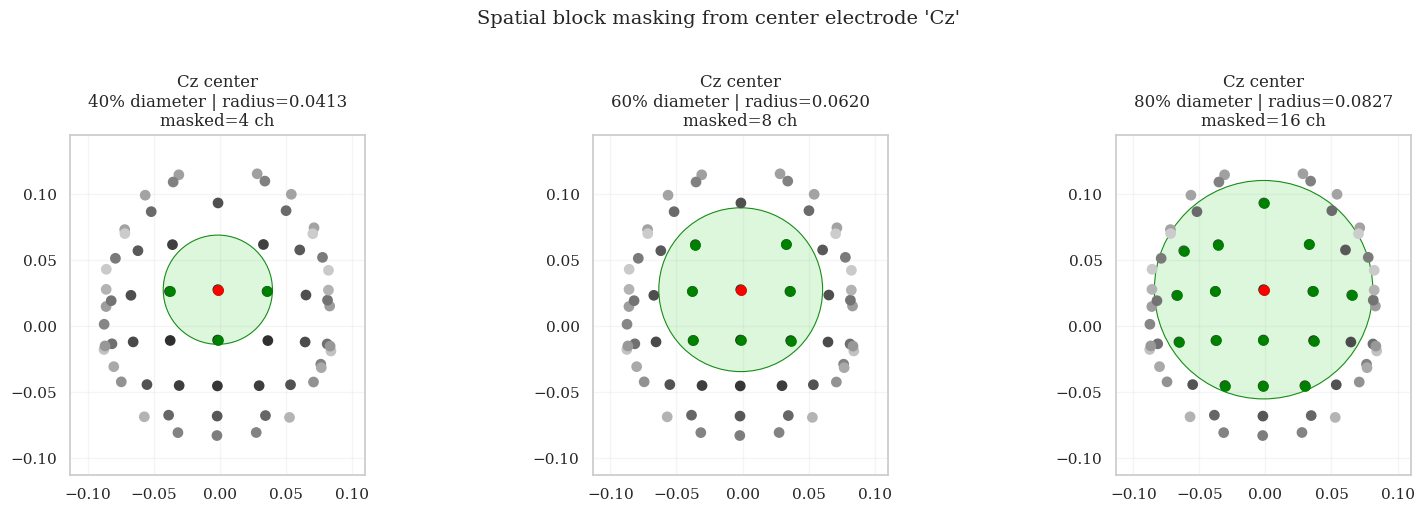

[2026-03-26 13:53:34] 40% mask around C6:
[2026-03-26 13:53:34]   radius: 0.041334
[2026-03-26 13:53:34]   masked channels (5): ['FC6', 'C4', 'T8', 'CP6', 'C6']

[2026-03-26 13:53:34] 60% mask around C6:
[2026-03-26 13:53:34]   radius: 0.062002
[2026-03-26 13:53:34]   masked channels (10): ['FC6', 'C4', 'T8', 'CP6', 'FC4', 'C6', 'CP4', 'FTT10h', 'TPP8h', 'TP8']

[2026-03-26 13:53:34] 80% mask around C6:
[2026-03-26 13:53:34]   radius: 0.082669
[2026-03-26 13:53:34]   masked channels (18): ['F4', 'F8', 'FC2', 'FC6', 'C4', 'T8', 'CP6', 'TP10', 'P4', 'P8', 'FC4', 'C2', 'C6', 'CP4', 'FTT10h', 'TPP8h', 'TP8', 'TPP10h']



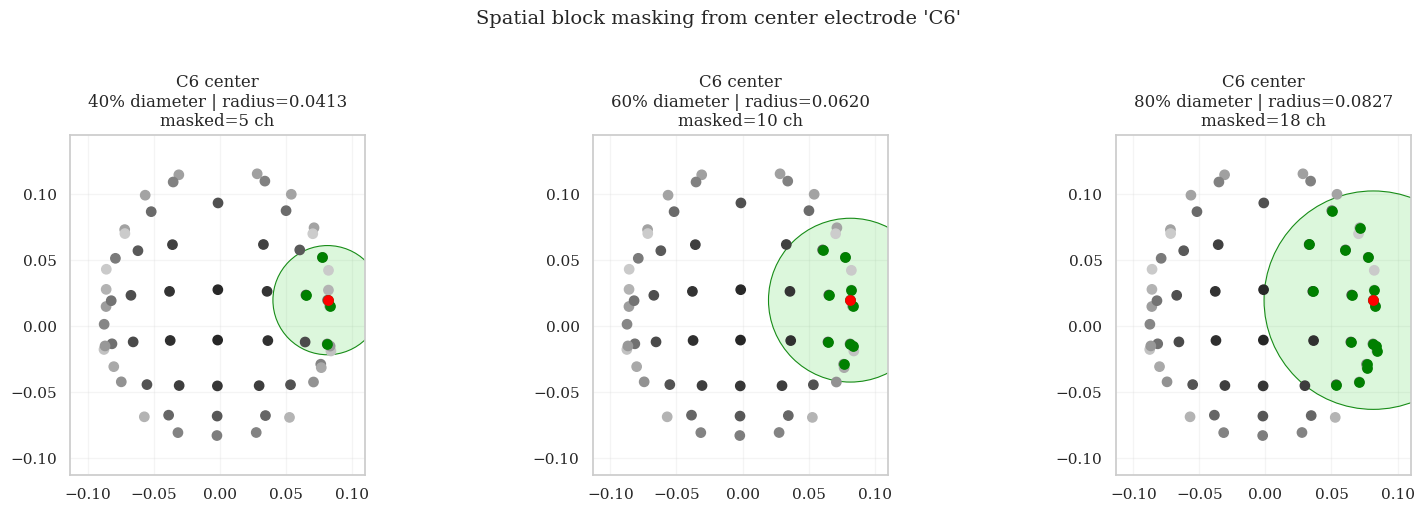

[2026-03-26 13:53:34] 40% mask around Oz:
[2026-03-26 13:53:34]   radius: 0.041334
[2026-03-26 13:53:34]   masked channels (4): ['O1', 'Oz', 'O2', 'POz']

[2026-03-26 13:53:34] 60% mask around Oz:
[2026-03-26 13:53:34]   radius: 0.062002
[2026-03-26 13:53:34]   masked channels (6): ['O1', 'Oz', 'O2', 'POz', 'PO3', 'PO4']

[2026-03-26 13:53:34] 80% mask around Oz:
[2026-03-26 13:53:34]   radius: 0.082669
[2026-03-26 13:53:34]   masked channels (13): ['P3', 'Pz', 'P4', 'PO9', 'O1', 'Oz', 'O2', 'PO10', 'P1', 'P2', 'POz', 'PO3', 'PO4']



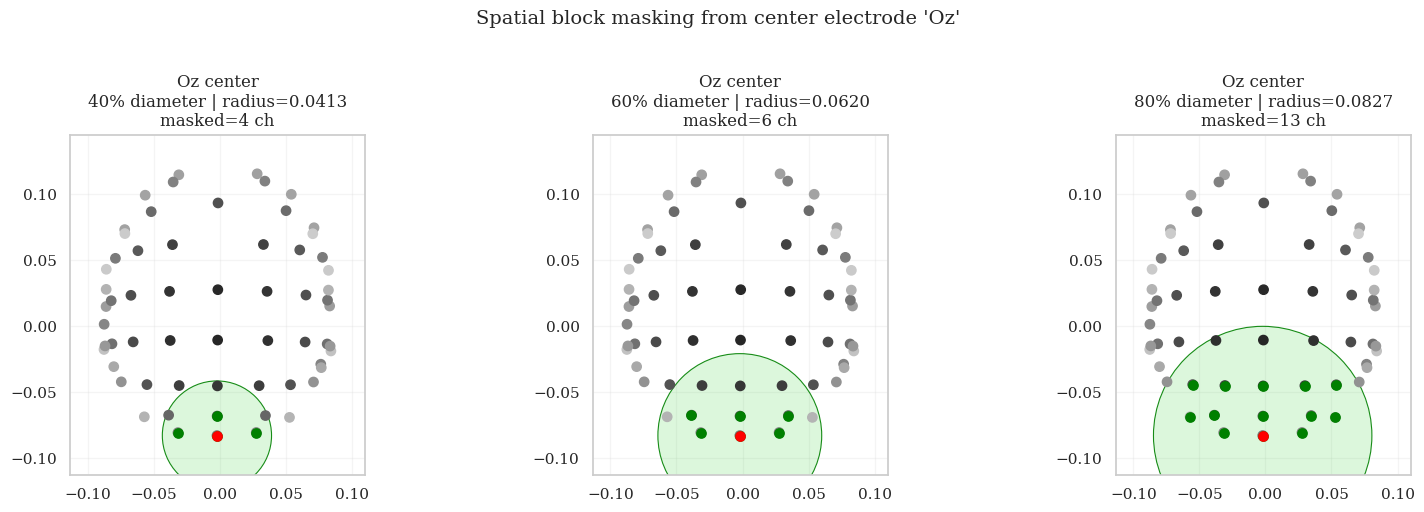

In [28]:
plot_sampler_masks(MASK_SAMPLER, center_name="Cz")
plot_sampler_masks(MASK_SAMPLER, center_name="C6")
plot_sampler_masks(MASK_SAMPLER, center_name="Oz")

[2026-03-26 13:53:35] 40% mask around Cz:
[2026-03-26 13:53:35]   radius: 0.041334
[2026-03-26 13:53:35]   masked channels (4): ['Cz', 'C1', 'C2', 'CPz']

[2026-03-26 13:53:35] 60% mask around Cz:
[2026-03-26 13:53:35]   radius: 0.062002
[2026-03-26 13:53:35]   masked channels (8): ['FC1', 'FC2', 'Cz', 'CP1', 'CP2', 'C1', 'C2', 'CPz']

[2026-03-26 13:53:35] 80% mask around Cz:
[2026-03-26 13:53:35]   radius: 0.082669
[2026-03-26 13:53:35]   masked channels (16): ['Fz', 'FC1', 'FC2', 'C3', 'Cz', 'C4', 'CP1', 'CP2', 'Pz', 'FC3', 'C1', 'C2', 'CP3', 'CPz', 'P1', 'P2']



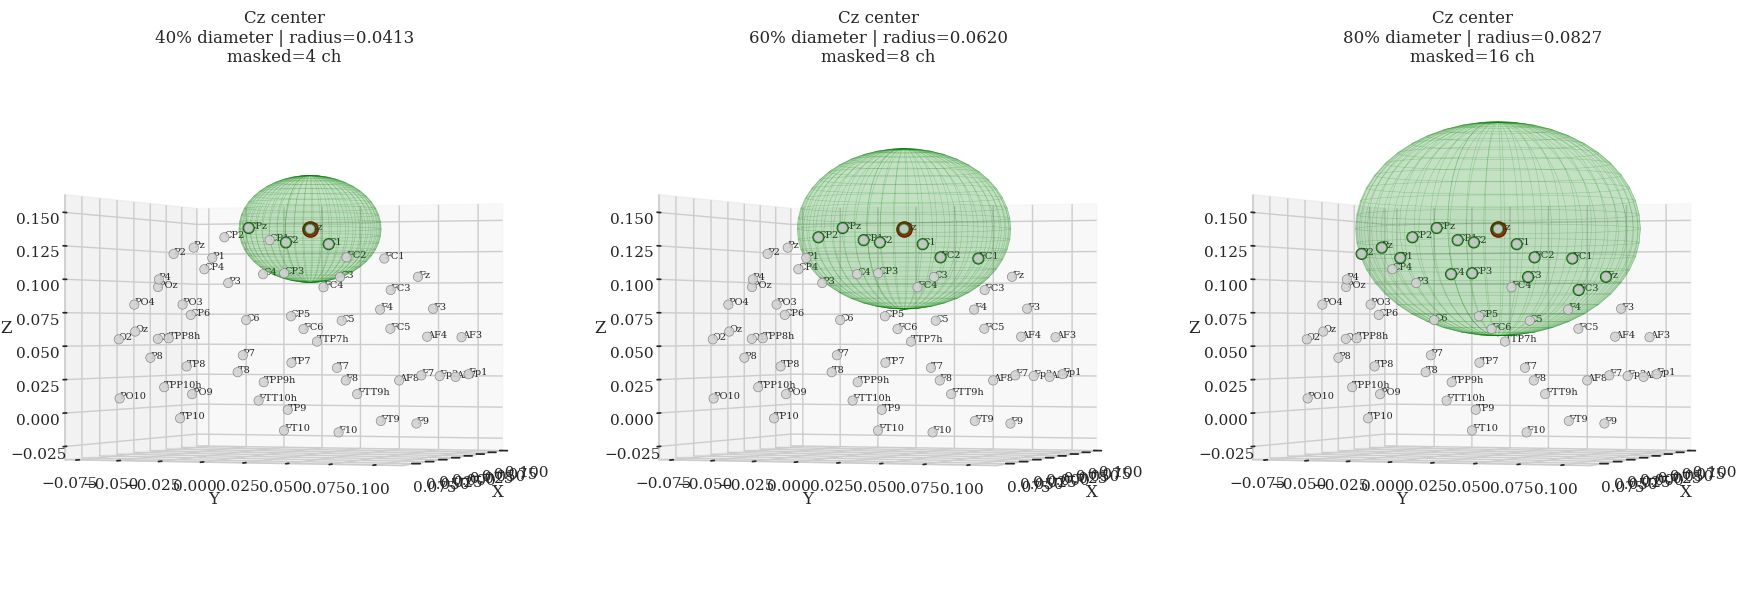

In [29]:
plot_sampler_masks_3d(MASK_SAMPLER, center_name="Cz", annotate=True, elev=0, azim=20)

## 4.3. Token-Routing Utilities

The helper functions below operate on a single sample at a time.
That keeps the routing logic correct even when the number of masked tokens varies across samples.

In [30]:
def expand_channel_mask_to_token_mask(mask_ch: torch.Tensor, n_tok_per_channel: int) -> torch.Tensor:
    """Expand a channel-level mask to token level.

    Supports either a single sample `(C,)` or a batch `(B, C)`.
    """
    if mask_ch.ndim == 1:
        return mask_ch.unsqueeze(-1).expand(-1, n_tok_per_channel).reshape(-1)
    if mask_ch.ndim == 2:
        return mask_ch.unsqueeze(-1).expand(-1, -1, n_tok_per_channel).reshape(mask_ch.shape[0], -1)
    raise ValueError(f"mask_ch must have ndim 1 or 2, got {mask_ch.ndim}")


def gather_visible_tokens_single(tokens: torch.Tensor, mask_tok: torch.Tensor) -> torch.Tensor:
    """Gather visible tokens for one sample.

    Parameters
    ----------
    tokens : FloatTensor `(N, D)`
    mask_tok : BoolTensor `(N,)`
    """
    return tokens[~mask_tok]


def gather_masked_tokens_single(tokens: torch.Tensor, mask_tok: torch.Tensor) -> torch.Tensor:
    """Gather masked tokens for one sample.

    Parameters
    ----------
    tokens : FloatTensor `(N, D)`
    mask_tok : BoolTensor `(N,)`
    """
    return tokens[mask_tok]

In [31]:
_, _fake_mask_tok, _fake_mask_info = MASK_SAMPLER.sample(2, device="cpu")

_fake_tokens = torch.randn(TOTAL_TOKENS, EMB_DIM)
_fake_visible = gather_visible_tokens_single(_fake_tokens, _fake_mask_tok[0])
_fake_masked = gather_masked_tokens_single(_fake_tokens, _fake_mask_tok[0])

print("Token-routing:")
print(f"  Full token shape:         {tuple(_fake_tokens.shape)}")
print(f"  Visible token shape:      {tuple(_fake_visible.shape)}")
print(f"  Masked token shape:       {tuple(_fake_masked.shape)}")
print(f"  Sample masked channels:   {_fake_mask_info['masked_channel_counts'][0]}")
print("Single-sample token routing validated OK.")

[2026-03-26 13:53:35] Token-routing:
[2026-03-26 13:53:35]   Full token shape:         (930, 64)
[2026-03-26 13:53:35]   Visible token shape:      (795, 64)
[2026-03-26 13:53:35]   Masked token shape:       (135, 64)
[2026-03-26 13:53:35]   Sample masked channels:   9
[2026-03-26 13:53:35] Single-sample token routing validated OK.


## 4.4. Predictor

The predictor maps student context to masked teacher targets.

Inputs:
- `student_context`: contextualized visible tokens `(1, N_vis, D)`
- `masked_pos_enc`: positional encodings of the masked positions `(1, N_masked, D)`

Output:
- predicted masked embeddings `(1, N_masked, D)`

In [32]:
class MaskedTokenPredictor(nn.Module):
    """Predicts masked token representations from student context.

    Architecture: Transformer decoder (cross-attention).

    Queries  = masked positional encodings  (B, N_masked, D)
    Keys/Vals = student contextual features (B, N_vis, D)
    Output   = predicted masked embeddings  (B, N_masked, D)
    """

    def __init__(
        self,
        d_model: int,
        nhead: int = 8,
        num_layers: int = 4,
        dim_feedforward: int = 256,
        dropout: float = 0.0,
    ):
        super().__init__()
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.output_norm = nn.LayerNorm(d_model)

    def forward(self, student_context: torch.Tensor, masked_pos_enc: torch.Tensor) -> torch.Tensor:
        """Predict masked token embeddings."""
        decoded = self.decoder(tgt=masked_pos_enc, memory=student_context)
        return self.output_norm(decoded)

In [33]:
PREDICTOR = MaskedTokenPredictor(
    d_model=EMB_DIM,
    nhead=CONFIG["predictor_nhead"],
    num_layers=CONFIG["predictor_n_layers"],
    dim_feedforward=CONFIG["predictor_dim_feedforward"],
).to(DEVICE)

predictor_param_count = sum(parameter.numel() for parameter in PREDICTOR.parameters())
print("MaskedTokenPredictor initialized:")
print(f"  d_model:          {EMB_DIM}")
print(f"  nhead:            {CONFIG['predictor_nhead']}")
print(f"  num_layers:       {CONFIG['predictor_n_layers']}")
print(f"  dim_feedforward:  {CONFIG['predictor_dim_feedforward']}")
print(f"  Total parameters: {predictor_param_count:,}")

_, _test_mask_tok, _ = MASK_SAMPLER.sample(1, device=DEVICE)
_test_n_masked = int(_test_mask_tok[0].sum().item())
_test_n_visible = int((~_test_mask_tok[0]).sum().item())

_fake_student_context = torch.randn(1, _test_n_visible, EMB_DIM, device=DEVICE)
_fake_masked_pos = torch.randn(1, _test_n_masked, EMB_DIM, device=DEVICE)

PREDICTOR.eval()
with torch.no_grad():
    _pred_out = PREDICTOR(_fake_student_context, _fake_masked_pos)

if _pred_out.shape != (1, _test_n_masked, EMB_DIM):
    raise RuntimeError(
        f"Predictor output shape mismatch: got {tuple(_pred_out.shape)} expected {(1, _test_n_masked, EMB_DIM)}"
    )

print("\nPredictor shape test: OK")
print(f"  student_context: {tuple(_fake_student_context.shape)}")
print(f"  masked_pos_enc:  {tuple(_fake_masked_pos.shape)}")
print(f"  prediction:      {tuple(_pred_out.shape)}")
PREDICTOR.train()

[2026-03-26 13:53:35] MaskedTokenPredictor initialized:
[2026-03-26 13:53:35]   d_model:          64
[2026-03-26 13:53:35]   nhead:            8
[2026-03-26 13:53:35]   num_layers:       4
[2026-03-26 13:53:35]   dim_feedforward:  256
[2026-03-26 13:53:35]   Total parameters: 267,136

[2026-03-26 13:53:36] Predictor shape test: OK
[2026-03-26 13:53:36]   student_context: (1, 780, 64)
[2026-03-26 13:53:36]   masked_pos_enc:  (1, 150, 64)
[2026-03-26 13:53:36]   prediction:      (1, 150, 64)


MaskedTokenPredictor(
  (decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (multihead_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm3): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.0, inplace=False)
        (dropout2): Dropout(p=0.0, inplace=False)
        (dropout3): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (ou

# 5. Training

## 5.1. Training Step, Validation Step, and EMA Update

The student/teacher/predictor path remains standard S-JEPA:
- teacher sees the full token sequence
- student sees only visible tokens
- predictor receives student context plus masked positional encodings
- masked-token L1 is computed against teacher contextual targets
- teacher is updated only through EMA

Because mask sizes vary across samples, each sample is processed independently inside the batch helper.

In [34]:
def masked_l1_loss(predicted: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """L1 loss on masked-token embeddings only."""
    return F.l1_loss(predicted, target)


@torch.no_grad()
def ema_update(student: nn.Module, teacher: nn.Module, ema_decay: float) -> None:
    """Update teacher parameters by exponential moving average from the student."""
    for student_param, teacher_param in zip(student.parameters(), teacher.parameters()):
        teacher_param.data.mul_(ema_decay).add_(student_param.data, alpha=1.0 - ema_decay)


def compute_single_sample_loss(x_single, student, teacher, predictor, mask_sampler, device, debug=False):
    """Compute the masked-token prediction loss for one sample."""
    x_single = x_single.unsqueeze(0).to(device)
    _, mask_tok, mask_info = mask_sampler.sample(1, device=device)
    mask_tok_single = mask_tok[0]

    if not bool(mask_tok_single.any()):
        raise RuntimeError("Mask sampler produced zero masked tokens.")
    if not bool((~mask_tok_single).any()):
        raise RuntimeError("Mask sampler masked every token in the sample.")

    teacher.eval()

    with torch.no_grad():
        teacher_local = teacher.feature_encoder(x_single)
        teacher_pos = teacher.pos_encoder(teacher_local)
        teacher_full_tokens = teacher_local + teacher_pos
        teacher_context = teacher.transformer.encoder(teacher_full_tokens)
        teacher_masked = teacher_context[:, mask_tok_single, :]

    student_local = student.feature_encoder(x_single)
    student_pos = student.pos_encoder(student_local)
    student_full_tokens = student_local + student_pos
    student_visible_tokens = student_full_tokens[:, ~mask_tok_single, :]
    masked_positional_queries = student_pos[:, mask_tok_single, :]
    student_context = student.transformer.encoder(student_visible_tokens)
    predicted_masked = predictor(student_context, masked_positional_queries)
    loss = masked_l1_loss(predicted_masked, teacher_masked.detach())

    sample_stats = {
        "center_channel": int(mask_info["center_indices"][0]),
        "masked_channels": int(mask_info["masked_channel_counts"][0]),
        "masked_tokens": int(mask_info["masked_token_counts"][0]),
        "visible_tokens": int((~mask_tok_single).sum().item()),
    }

    if debug:
        print("  [debug] first-sample training path:")
        print(f"    x_single:             {tuple(x_single.shape)}")
        print(f"    teacher_full_tokens:  {tuple(teacher_full_tokens.shape)}")
        print(f"    student_visible:      {tuple(student_visible_tokens.shape)}")
        print(f"    masked_queries:       {tuple(masked_positional_queries.shape)}")
        print(f"    predicted_masked:     {tuple(predicted_masked.shape)}")
        print(f"    teacher_masked:       {tuple(teacher_masked.shape)}")
        print(f"    center_channel:       {sample_stats['center_channel']}")
        print(f"    masked_channels:      {sample_stats['masked_channels']}")
        print(f"    masked_tokens:        {sample_stats['masked_tokens']}")
        print(f"    visible_tokens:       {sample_stats['visible_tokens']}")
        print(f"    sample_loss:          {loss.item():.6f}")

    return loss, sample_stats

def compute_batch_loss(
    X_cpu,
    student,
    teacher,
    predictor,
    mask_sampler,
    device,
    debug=False,
):
    sample_losses = []
    sample_stats = []

    for sample_idx in range(X_cpu.shape[0]):
        # move only one sample to device
        x_sample = X_cpu[sample_idx].float().to(device)

        sample_loss, stats = compute_single_sample_loss(
            x_sample,
            student=student,
            teacher=teacher,
            predictor=predictor,
            mask_sampler=mask_sampler,
            device=device,
            debug=debug and sample_idx == 0,
        )

        sample_losses.append(sample_loss)
        sample_stats.append(stats)

        # release per-sample tensors sooner
        del x_sample
        if device.type == "mps":
            torch.mps.empty_cache()

    batch_loss = torch.stack(sample_losses).mean()

    batch_stats = {
        "mean_masked_channels": float(sum(s["masked_channels"] for s in sample_stats) / len(sample_stats)),
        "mean_masked_tokens": float(sum(s["masked_tokens"] for s in sample_stats) / len(sample_stats)),
        "mean_visible_tokens": float(sum(s["visible_tokens"] for s in sample_stats) / len(sample_stats)),
        "sample_stats": sample_stats,
    }
    return batch_loss, batch_stats


def pretraining_step(
    X,
    student,
    teacher,
    predictor,
    mask_sampler,
    optimizer,
    ema_decay,
    device,
    debug=False,
):
    # keep X on CPU here
    optimizer.zero_grad(set_to_none=True)

    batch_loss, batch_stats = compute_batch_loss(
        X_cpu=X,
        student=student,
        teacher=teacher,
        predictor=predictor,
        mask_sampler=mask_sampler,
        device=device,
        debug=debug,
    )

    batch_loss.backward()
    optimizer.step()
    ema_update(student.transformer.encoder, teacher.transformer.encoder, ema_decay)

    return {
        "loss": float(batch_loss.item()),
        "mean_masked_channels": batch_stats["mean_masked_channels"],
        "mean_masked_tokens": batch_stats["mean_masked_tokens"],
    }


def evaluate_pretraining_batch(X, student, teacher, predictor, mask_sampler, device):
    """Evaluate one validation batch without parameter updates."""
    student.eval()
    predictor.eval()
    teacher.eval()

    X = X.to(device)
    with torch.no_grad():
        batch_loss, batch_stats = compute_batch_loss(
            X,
            student=student,
            teacher=teacher,
            predictor=predictor,
            mask_sampler=mask_sampler,
            device=device,
            debug=False,
        )

    return {
        "loss": float(batch_loss.item()),
        **batch_stats,
    }

In [35]:
OPTIMIZER = torch.optim.Adam(
    list(STUDENT.parameters()) + list(PREDICTOR.parameters()),
)

TRAIN_LOADER = DataLoader(
    TRAIN_WINDOWS_DATASET,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=0,
    drop_last=True,
)
VAL_LOADER = DataLoader(
    VAL_WINDOWS_DATASET,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=0,
    drop_last=False,
)

print("Optimizer: Adam")
print(f"Train loader batches: {len(TRAIN_LOADER)}")
print(f"Val loader batches:   {len(VAL_LOADER)}")

print("\nRunning first-batch debug...")
set_seed(CONFIG["seed"])
_debug_batch = next(iter(TRAIN_LOADER))
_debug_X = _debug_batch[0].float()
_debug_train_result = pretraining_step(
    X=_debug_X,
    student=STUDENT,
    teacher=TEACHER,
    predictor=PREDICTOR,
    mask_sampler=MASK_SAMPLER,
    optimizer=OPTIMIZER,
    ema_decay=CONFIG["ema_decay"],
    device=DEVICE,
    debug=True,
)
print(f"  First training-batch loss: {_debug_train_result['loss']:.6f}")
print(f"  Mean masked channels:      {_debug_train_result['mean_masked_channels']:.2f}")
print(f"  Mean masked tokens:        {_debug_train_result['mean_masked_tokens']:.2f}")

_validation_batch = next(iter(VAL_LOADER))
_validation_result = evaluate_pretraining_batch(
    X=_validation_batch[0].float(),
    student=STUDENT,
    teacher=TEACHER,
    predictor=PREDICTOR,
    mask_sampler=MASK_SAMPLER,
    device=DEVICE,
)
print(f"  First validation-batch loss: {_validation_result['loss']:.6f}")

if not np.isfinite(_debug_train_result["loss"]):
    raise RuntimeError("First training batch produced a non-finite loss.")
if not np.isfinite(_validation_result["loss"]):
    raise RuntimeError("First validation batch produced a non-finite loss.")

[2026-03-26 13:53:36] Optimizer: Adam
[2026-03-26 13:53:36] Train loader batches: 21
[2026-03-26 13:53:36] Val loader batches:   12

[2026-03-26 13:53:36] Running first-batch debug...
[2026-03-26 13:53:37]   [debug] first-sample training path:
[2026-03-26 13:53:37]     x_single:             (1, 62, 2048)
[2026-03-26 13:53:37]     teacher_full_tokens:  (1, 930, 64)
[2026-03-26 13:53:37]     student_visible:      (1, 795, 64)
[2026-03-26 13:53:37]     masked_queries:       (1, 135, 64)
[2026-03-26 13:53:37]     predicted_masked:     (1, 135, 64)
[2026-03-26 13:53:37]     teacher_masked:       (1, 135, 64)
[2026-03-26 13:53:37]     center_channel:       40
[2026-03-26 13:53:37]     masked_channels:      9
[2026-03-26 13:53:37]     masked_tokens:        135
[2026-03-26 13:53:37]     visible_tokens:       795
[2026-03-26 13:53:37]     sample_loss:          nan


RuntimeError: MPS backend out of memory (MPS allocated: 20.05 GiB, other allocations: 80.30 MiB, max allowed: 20.13 GiB). Tried to allocate 5.38 MiB on private pool. Use PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0 to disable upper limit for memory allocations (may cause system failure).

## 5.2. Epoch Loop, Validation, Early Stopping, and Checkpoints

Each epoch now runs:
- one full training pass over `TRAIN_LOADER`
- one full validation pass over `VAL_LOADER`
- latest checkpoint save
- best checkpoint update based on validation loss
- patience-10 early stopping on validation loss
- `epoch_metrics.jsonl` append

In [36]:
import time


def build_backbone_export_metadata():
    """Metadata needed to reconstruct the pretrained student backbone later."""
    return {
        "conv_layers_spec": [list(spec) for spec in _DEFAULT_CONV_LAYER_SPEC],
        "sfreq": CONFIG["sfreq"],
        "input_window_seconds": INPUT_WINDOW_SECONDS,
        "chs_info": CHS_INFO,
        "ch_names": CH_NAMES,
        "token_geometry": {
            "n_channels": N_CHANNELS,
            "n_tok_per_channel": N_TOK_PER_CHANNEL,
            "emb_dim": EMB_DIM,
            "total_tokens": TOTAL_TOKENS,
        },
        "masking_config": {
            "strategy": CONFIG["masking_strategy"],
            "mask_diameter_percent": CONFIG["mask_diameter_percent"],
            "head_diameter": MASK_SAMPLER.head_diameter,
            "mask_diameter": MASK_SAMPLER.mask_diameter,
            "mask_radius": MASK_SAMPLER.mask_radius,
        },
        "preprocessing_config": {
            "sfreq": CONFIG["sfreq"],
            "bandpass_low": CONFIG["bandpass_low"],
            "bandpass_high": CONFIG["bandpass_high"],
            "pretrain_duration_s": CONFIG["pretrain_duration_s"],
            "sampling_interval_s": CONFIG["sampling_interval_s"],
            "window_size_samples": WINDOW_SIZE_SAMPLES,
            "sampling_interval_samples": SAMPLING_INTERVAL_SAMPLES,
        },
        "subject_split": {
            "train_subject_ids": TRAIN_SUBJECTS,
            "val_subject_ids": VAL_SUBJECTS,
            "excluded_subject_ids": DOWNSTREAM_ONLY_SUBJECTS,
        },
    }


BACKBONE_EXPORT_METADATA = build_backbone_export_metadata()


def save_checkpoint(artifact_dir, tag, student, teacher, predictor, optimizer, epoch, epoch_record, metrics_so_far):
    """Save a full training checkpoint."""
    checkpoint = {
        "epoch": epoch,
        "epoch_record": epoch_record,
        "student_state_dict": student.state_dict(),
        "teacher_state_dict": teacher.state_dict(),
        "predictor_state_dict": predictor.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "metrics": metrics_so_far,
        "backbone_export_metadata": BACKBONE_EXPORT_METADATA,
    }
    checkpoint_path = Path(artifact_dir) / f"checkpoint_{tag}.pt"
    torch.save(checkpoint, checkpoint_path)
    return str(checkpoint_path)


def save_student_backbone_export(artifact_dir, tag, student):
    """Save a dedicated student-backbone export for downstream fine-tuning."""
    export_payload = {
        "student_backbone_state_dict": student.state_dict(),
        **BACKBONE_EXPORT_METADATA,
    }
    export_path = Path(artifact_dir) / f"student_backbone_{tag}.pt"
    torch.save(export_payload, export_path)
    return str(export_path)


def append_epoch_metrics(artifact_dir, epoch_record):
    """Append one epoch record to epoch_metrics.jsonl."""
    epoch_metrics_path = Path(artifact_dir) / "epoch_metrics.jsonl"
    with open(epoch_metrics_path, "a") as metric_file:
        metric_file.write(json.dumps(epoch_record) + "\n")

In [37]:
def run_pretraining_epoch(
    epoch,
    split_name,
    dataloader,
    training,
    student,
    teacher,
    predictor,
    mask_sampler,
    optimizer,
    ema_decay,
    device,
):
    """Run one train or validation epoch."""
    epoch_start = time.time()
    batch_losses = []
    masked_channels = []
    masked_tokens = []
    visible_tokens = []

    for batch in dataloader:
        X = batch[0].float()
        if training:
            batch_result = pretraining_step(
                X=X,
                student=student,
                teacher=teacher,
                predictor=predictor,
                mask_sampler=mask_sampler,
                optimizer=optimizer,
                ema_decay=ema_decay,
                device=device,
                debug=False,
            )
        else:
            batch_result = evaluate_pretraining_batch(
                X=X,
                student=student,
                teacher=teacher,
                predictor=predictor,
                mask_sampler=mask_sampler,
                device=device,
            )

        batch_losses.append(batch_result["loss"])
        masked_channels.append(batch_result["mean_masked_channels"])
        masked_tokens.append(batch_result["mean_masked_tokens"])
        visible_tokens.append(batch_result["mean_visible_tokens"])

    if not batch_losses:
        raise RuntimeError(f"{split_name} dataloader produced zero batches.")

    epoch_time_s = time.time() - epoch_start
    return {
        "epoch": int(epoch),
        "split": split_name,
        "mean_loss": float(np.mean(batch_losses)),
        "min_loss": float(np.min(batch_losses)),
        "max_loss": float(np.max(batch_losses)),
        "mean_masked_channels": float(np.mean(masked_channels)),
        "mean_masked_tokens": float(np.mean(masked_tokens)),
        "mean_visible_tokens": float(np.mean(visible_tokens)),
        "n_batches": int(len(batch_losses)),
        "epoch_time_s": round(epoch_time_s, 2),
    }

In [38]:
print("=" * 70)
print("STARTING LEE2019 S-JEPA PRETRAINING")
print("=" * 70)
print(f"Paradigms:            {CONFIG['paradigm_names']}")
print(f"Train subjects:       {TRAIN_SUBJECTS}")
print(f"Validation subjects:  {VAL_SUBJECTS}")
print(f"Excluded subjects:    {DOWNSTREAM_ONLY_SUBJECTS}")
print(f"Train windows:        {len(TRAIN_WINDOWS_DATASET)}")
print(f"Validation windows:   {len(VAL_WINDOWS_DATASET)}")
print(f"Pretrain duration:    {CONFIG['pretrain_duration_s']} s")
print(f"Sampling interval:    {CONFIG['sampling_interval_s']} s")
print(f"Mask diameter:        {CONFIG['mask_diameter_percent']}%")
print(f"Batch size:           {CONFIG['batch_size']}")
print(f"Epoch limit:          {CONFIG['n_epochs']}")
print(f"Early-stop patience:  {CONFIG['early_stopping_patience']}")
print(f"EMA decay:            {CONFIG['ema_decay']}")
print(f"Device:               {DEVICE}")
print("=" * 70)

set_seed(CONFIG["seed"])

EPOCH_METRICS = []
BEST_VAL_LOSS = float("inf")
BEST_EPOCH = -1
PATIENCE_COUNTER = 0
STOP_REASON = "max_epochs_reached"

for epoch in range(1, CONFIG["n_epochs"] + 1):
    train_metrics = run_pretraining_epoch(
        epoch=epoch,
        split_name="train",
        dataloader=TRAIN_LOADER,
        training=True,
        student=STUDENT,
        teacher=TEACHER,
        predictor=PREDICTOR,
        mask_sampler=MASK_SAMPLER,
        optimizer=OPTIMIZER,
        ema_decay=CONFIG["ema_decay"],
        device=DEVICE,
    )
    val_metrics = run_pretraining_epoch(
        epoch=epoch,
        split_name="validation",
        dataloader=VAL_LOADER,
        training=False,
        student=STUDENT,
        teacher=TEACHER,
        predictor=PREDICTOR,
        mask_sampler=MASK_SAMPLER,
        optimizer=OPTIMIZER,
        ema_decay=CONFIG["ema_decay"],
        device=DEVICE,
    )

    improved = val_metrics["mean_loss"] < BEST_VAL_LOSS
    if improved:
        BEST_VAL_LOSS = val_metrics["mean_loss"]
        BEST_EPOCH = epoch
        PATIENCE_COUNTER = 0
    else:
        PATIENCE_COUNTER += 1

    epoch_record = {
        "epoch": epoch,
        "train_loss": train_metrics["mean_loss"],
        "val_loss": val_metrics["mean_loss"],
        "train_masked_channels": train_metrics["mean_masked_channels"],
        "val_masked_channels": val_metrics["mean_masked_channels"],
        "train_masked_tokens": train_metrics["mean_masked_tokens"],
        "val_masked_tokens": val_metrics["mean_masked_tokens"],
        "train_visible_tokens": train_metrics["mean_visible_tokens"],
        "val_visible_tokens": val_metrics["mean_visible_tokens"],
        "train_time_s": train_metrics["epoch_time_s"],
        "val_time_s": val_metrics["epoch_time_s"],
        "best_val_loss": BEST_VAL_LOSS,
        "best_epoch": BEST_EPOCH,
        "patience_counter": PATIENCE_COUNTER,
        "improved_val": improved,
    }
    EPOCH_METRICS.append(epoch_record)
    append_epoch_metrics(ARTIFACT_DIR, epoch_record)

    save_checkpoint(
        ARTIFACT_DIR,
        "latest",
        STUDENT,
        TEACHER,
        PREDICTOR,
        OPTIMIZER,
        epoch,
        epoch_record,
        EPOCH_METRICS,
    )
    save_student_backbone_export(ARTIFACT_DIR, "latest", STUDENT)

    if improved:
        save_checkpoint(
            ARTIFACT_DIR,
            "best",
            STUDENT,
            TEACHER,
            PREDICTOR,
            OPTIMIZER,
            epoch,
            epoch_record,
            EPOCH_METRICS,
        )
        save_student_backbone_export(ARTIFACT_DIR, "best", STUDENT)

    print(
        f"Epoch {epoch:3d}/{CONFIG['n_epochs']}  "
        f"train_loss={train_metrics['mean_loss']:.6f}  "
        f"val_loss={val_metrics['mean_loss']:.6f}  "
        f"best_val={BEST_VAL_LOSS:.6f}  "
        f"patience={PATIENCE_COUNTER}/{CONFIG['early_stopping_patience']}  "
        f"train_time={train_metrics['epoch_time_s']:.1f}s  "
        f"val_time={val_metrics['epoch_time_s']:.1f}s"
    )

    if PATIENCE_COUNTER >= CONFIG["early_stopping_patience"]:
        STOP_REASON = "early_stopping"
        print(
            f"Early stopping triggered after epoch {epoch}: "
            f"no validation improvement for {CONFIG['early_stopping_patience']} epochs."
        )
        break

print("=" * 70)
print(f"Training complete. Best validation loss: {BEST_VAL_LOSS:.6f} at epoch {BEST_EPOCH}.")
print(f"Stop reason: {STOP_REASON}")
print("=" * 70)

[2026-03-26 13:54:51] ======================================================================
[2026-03-26 13:54:51] STARTING LEE2019 S-JEPA PRETRAINING
[2026-03-26 13:54:51] ======================================================================
[2026-03-26 13:54:51] Paradigms:            ['SSVEP']
[2026-03-26 13:54:51] Train subjects:       [49, 50, 51, 52]
[2026-03-26 13:54:51] Validation subjects:  [53, 54]
[2026-03-26 13:54:51] Excluded subjects:    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48]
[2026-03-26 13:54:51] Train windows:        642
[2026-03-26 13:54:51] Validation windows:   358
[2026-03-26 13:54:51] Pretrain duration:    16.0 s
[2026-03-26 13:54:51] Sampling interval:    16 s
[2026-03-26 13:54:51] Mask diameter:        60%
[2026-03-26 13:54:51] Batch size:           30
[2026-03-26 13:54:51] Epoch limit:          300
[2026-03-26 13:54:51]

RuntimeError: MPS backend out of memory (MPS allocated: 20.05 GiB, other allocations: 60.30 MiB, max allowed: 20.13 GiB). Tried to allocate 19.29 MiB on private pool. Use PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0 to disable upper limit for memory allocations (may cause system failure).

# 6. Diagnostics

Lightweight post-training checks for reproducibility:
- train/validation loss history
- mask coverage statistics
- one-batch end-to-end shape inspection

## 6.1. Loss Curve Summary

In [ ]:
print("=" * 70)
print("LOSS HISTORY SUMMARY")
print("=" * 70)

if EPOCH_METRICS:
    train_losses = [record["train_loss"] for record in EPOCH_METRICS]
    val_losses = [record["val_loss"] for record in EPOCH_METRICS]
    total_train_time = sum(record["train_time_s"] for record in EPOCH_METRICS)
    total_val_time = sum(record["val_time_s"] for record in EPOCH_METRICS)

    print(f"  Epochs completed:     {len(EPOCH_METRICS)}")
    print(f"  First train loss:     {train_losses[0]:.6f}")
    print(f"  Last train loss:      {train_losses[-1]:.6f}")
    print(f"  First val loss:       {val_losses[0]:.6f}")
    print(f"  Last val loss:        {val_losses[-1]:.6f}")
    print(f"  Best val loss:        {BEST_VAL_LOSS:.6f} (epoch {BEST_EPOCH})")
    print(f"  Total train time:     {total_train_time:.1f} s")
    print(f"  Total validation time:{total_val_time:.1f} s")
    print(f"  Stop reason:          {STOP_REASON}")
else:
    print("  No epoch metrics recorded.")

## 6.2. Mask Coverage Summary

In [ ]:
def summarize_mask_coverage(mask_sampler: RandomSpatialBlockMaskSampler, n_samples: int = 200):
    """Sample mask coverage statistics for the current radius-based sampler."""
    masked_channel_counts = []
    masked_token_counts = []

    for _ in range(n_samples):
        _, _, mask_info = mask_sampler.sample(1, device="cpu")
        masked_channel_counts.append(mask_info["masked_channel_counts"][0])
        masked_token_counts.append(mask_info["masked_token_counts"][0])

    mask_stats = {
        "n_channels": mask_sampler.n_channels,
        "n_tok_per_channel": mask_sampler.n_tok_per_channel,
        "head_diameter": mask_sampler.head_diameter,
        "mask_diameter_percent": mask_sampler.mask_diameter_percent,
        "mask_diameter": mask_sampler.mask_diameter,
        "mask_radius": mask_sampler.mask_radius,
        "masked_channels_mean": float(np.mean(masked_channel_counts)),
        "masked_channels_min": int(np.min(masked_channel_counts)),
        "masked_channels_max": int(np.max(masked_channel_counts)),
        "masked_tokens_mean": float(np.mean(masked_token_counts)),
        "masked_tokens_min": int(np.min(masked_token_counts)),
        "masked_tokens_max": int(np.max(masked_token_counts)),
        "n_samples": int(n_samples),
    }

    print("Mask coverage statistics:")
    for key, value in mask_stats.items():
        print(f"  {key}: {value}")

    mask_stats_path = ARTIFACT_DIR / "mask_stats.json"
    with open(mask_stats_path, "w") as output_file:
        json.dump(mask_stats, output_file, indent=2)
    print(f"\nMask stats saved to: {mask_stats_path}")

    return mask_stats


MASK_STATS = summarize_mask_coverage(MASK_SAMPLER)

## 6.3. One-Batch End-to-End Inspector

In [ ]:
def inspect_one_batch_end_to_end(student, teacher, predictor, mask_sampler, windows_dataset, device):
    """Inspect one validation batch end to end using the first sample in the batch."""
    loader = DataLoader(windows_dataset, batch_size=4, shuffle=False)
    batch = next(iter(loader))
    x_batch = batch[0].float().to(device)
    x_single = x_batch[0].unsqueeze(0)

    student.eval()
    teacher.eval()
    predictor.eval()

    mask_ch, mask_tok, mask_info = mask_sampler.sample(1, device=device)
    mask_tok_single = mask_tok[0]

    with torch.no_grad():
        teacher_local = teacher.feature_encoder(x_single)
        teacher_pos = teacher.pos_encoder(teacher_local)
        teacher_full = teacher_local + teacher_pos
        teacher_context = teacher.transformer.encoder(teacher_full)
        teacher_masked = teacher_context[:, mask_tok_single, :]

        student_local = student.feature_encoder(x_single)
        student_pos = student.pos_encoder(student_local)
        student_full = student_local + student_pos
        student_visible = student_full[:, ~mask_tok_single, :]
        masked_queries = student_pos[:, mask_tok_single, :]
        student_context = student.transformer.encoder(student_visible)
        predicted_masked = predictor(student_context, masked_queries)
        loss_value = masked_l1_loss(predicted_masked, teacher_masked)

    print("=" * 70)
    print("ONE-BATCH END-TO-END INSPECTION")
    print("=" * 70)
    print(f"  x_single:            {tuple(x_single.shape)}")
    print(f"  teacher_full:        {tuple(teacher_full.shape)}")
    print(f"  student_visible:     {tuple(student_visible.shape)}")
    print(f"  masked_queries:      {tuple(masked_queries.shape)}")
    print(f"  predicted_masked:    {tuple(predicted_masked.shape)}")
    print(f"  teacher_masked:      {tuple(teacher_masked.shape)}")
    print(f"  center_channel:      {mask_info['center_indices'][0]}")
    print(f"  masked_channels:     {mask_info['masked_channel_counts'][0]}")
    print(f"  masked_tokens:       {mask_info['masked_token_counts'][0]}")
    print(f"  inspection_loss:     {loss_value.item():.6f}")
    print("=" * 70)


inspect_one_batch_end_to_end(STUDENT, TEACHER, PREDICTOR, MASK_SAMPLER, VAL_WINDOWS_DATASET, DEVICE)

# 7. Outputs

In [ ]:
metrics_path = ARTIFACT_DIR / "metrics.json"
with open(metrics_path, "w") as output_file:
    json.dump(EPOCH_METRICS, output_file, indent=2)
print(f"Epoch metrics saved to:           {metrics_path}")

run_metadata = {
    "run_id": RUN_ID,
    "artifact_dir": str(ARTIFACT_DIR),
    "paradigms": CONFIG["paradigm_names"],
    "subject_split": {
        "train_subject_ids": TRAIN_SUBJECTS,
        "val_subject_ids": VAL_SUBJECTS,
        "excluded_subject_ids": DOWNSTREAM_ONLY_SUBJECTS,
    },
    "datasets": {
        "train_recordings": len(TRAIN_RAW_DATASET.datasets),
        "val_recordings": len(VAL_RAW_DATASET.datasets),
        "train_windows": len(TRAIN_WINDOWS_DATASET),
        "val_windows": len(VAL_WINDOWS_DATASET),
    },
    "preprocessing": BACKBONE_EXPORT_METADATA["preprocessing_config"],
    "masking": BACKBONE_EXPORT_METADATA["masking_config"],
    "model": BACKBONE_EXPORT_METADATA["token_geometry"],
    "training": {
        "batch_size": CONFIG["batch_size"],
        "learning_rate": CONFIG["learning_rate"],
        "weight_decay": CONFIG["weight_decay"],
        "ema_decay": CONFIG["ema_decay"],
        "early_stopping_patience": CONFIG["early_stopping_patience"],
        "epochs_completed": len(EPOCH_METRICS),
        "best_epoch": BEST_EPOCH,
        "best_val_loss": BEST_VAL_LOSS,
        "stop_reason": STOP_REASON,
        "device": str(DEVICE),
    },
    "artifacts": {
        "config": str(ARTIFACT_DIR / "config.json"),
        "run_log": str(LOG_PATH),
        "metrics": str(metrics_path),
        "epoch_metrics_jsonl": str(ARTIFACT_DIR / "epoch_metrics.jsonl"),
        "checkpoint_latest": str(ARTIFACT_DIR / "checkpoint_latest.pt"),
        "checkpoint_best": str(ARTIFACT_DIR / "checkpoint_best.pt"),
        "student_backbone_latest": str(ARTIFACT_DIR / "student_backbone_latest.pt"),
        "student_backbone_best": str(ARTIFACT_DIR / "student_backbone_best.pt"),
        "mask_stats": str(ARTIFACT_DIR / "mask_stats.json"),
    },
}

metadata_path = ARTIFACT_DIR / "run_metadata.json"
with open(metadata_path, "w") as output_file:
    json.dump(run_metadata, output_file, indent=2, default=str)
print(f"Run metadata saved to:            {metadata_path}")

In [ ]:
print("\n" + "=" * 70)
print("EXPERIMENT SUMMARY")
print("=" * 70)
print(f"Run ID:            {RUN_ID}")
print(f"Artifacts:         {ARTIFACT_DIR}")
print()
print("Subject split:")
print(f"  Train:           {TRAIN_SUBJECTS}")
print(f"  Validation:      {VAL_SUBJECTS}")
print(f"  Excluded:        {DOWNSTREAM_ONLY_SUBJECTS}")
print()
print("Data:")
print(f"  Paradigms:       {CONFIG['paradigm_names']}")
print(f"  Train windows:   {len(TRAIN_WINDOWS_DATASET)}")
print(f"  Val windows:     {len(VAL_WINDOWS_DATASET)}")
print(f"  Window seconds:  {CONFIG['pretrain_duration_s']}")
print(f"  Interval secs:   {CONFIG['sampling_interval_s']}")
print()
print("Masking:")
print(f"  Diameter %:      {CONFIG['mask_diameter_percent']}")
print(f"  Radius:          {MASK_SAMPLER.mask_radius:.6f}")
print()
print("Results:")
if EPOCH_METRICS:
    print(f"  Epochs run:      {len(EPOCH_METRICS)}")
    print(f"  Best epoch:      {BEST_EPOCH}")
    print(f"  Best val loss:   {BEST_VAL_LOSS:.6f}")
    print(f"  Final val loss:  {EPOCH_METRICS[-1]['val_loss']:.6f}")
    print(f"  Stop reason:     {STOP_REASON}")
else:
    print("  No training epochs recorded.")
print()
print("Artifact files:")
for artifact_name, artifact_path in run_metadata["artifacts"].items():
    print(f"  {artifact_name}: {artifact_path}")
print("=" * 70)